# Step 1: Dataset Description and Exploration

In [1]:
# === Library Imports ===
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import os, json, random, shutil
import torch
import torchvision
from torchvision.models.detection import maskrcnn_resnet50_fpn
from torchvision.transforms import functional as F
from torch.utils.data import Dataset, DataLoader
import cv2
import glob
import numpy as np
from tqdm import tqdm
import time
from ultralytics import YOLO
from Dataset import SARD2YOLODataset, collate_fn
from torchmetrics.detection import MeanAveragePrecision
from torchvision.models.detection import ssd300_vgg16
from torchvision.models.detection.ssd import SSDHead


In [28]:
#  Configuration and Global Variables

#  Paths and Files
ROOT_PATH = Path(r"dataset\labels")
IMG_TEST_PATH = Path(r"./dataset/images/test")
IMG_TEST_SAMPLE = "gss1453_jpg.rf.acd3851415441b6b4561d567e70d048d.jpg"

# Paths for augmentation (used in Step 2)
AUG_IMG_SOURCE_TRAIN = './dataset_augmente/images/train'
AUG_LBL_SOURCE_TRAIN = './dataset_augmente/labels/train'
AUG_IMG_SOURCE_VALID = './dataset_augmente/images/valid'
AUG_LBL_SOURCE_VALID = './dataset_augmente/labels/valid'
AUG_IMG_SOURCE_TEST = './dataset_augmente/images/test'
AUG_LBL_SOURCE_TEST = './dataset_augmente/labels/test'

# Model paths and configuration (used in Step 3)
DATA_YAML = "data.yaml"
YOLO_PT = "yolo11n.pt"
YOLO_BEST_PT = 'runs/train/sard2_yolo11_augmented/weights/best.pt'
MASK_RCNN_PATH = "mask_rcnn_FINAL_MODEL_config2.pth"

#  Model Parameters
DEVICE = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
IMG_SIZE = 640
BATCH_SIZE_YOLO = 25
BATCH_SIZE_MASKRCNN = 2
NUM_WORKERS = 2
NUM_EPOCHS_YOLO = 100
NUM_EPOCHS_MASKRCNN = 20

# --- Dataset Configuration ---
CLASSES = {
    0: "Running",
    1: "Walking",
    2: "Laying_down",
    3: "Not_defined",
    4: "Seated",
    5: "Stands"
}

# +1 for background for Mask R-CNN
NUM_CLASSES_MASKRCNN = len(CLASSES) + 1

QUANT_VARS = ["x_center", "y_center", "width", "height"]

#  Display GPU Information
if torch.cuda.is_available():
    print(f"GPU detected: {torch.cuda.get_device_name(0)}")
    print(f"Available VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    torch.backends.cudnn.benchmark = True
    torch.cuda.empty_cache()
else:
    print("No GPU detected, using CPU")

GPU detected: NVIDIA GeForce RTX 3050 Laptop GPU
Available VRAM: 4.29 GB


## 1.1 - Variable Presentation: 

In the dataset, we have several columns describing the YOLO annotations: 

| Column | Description |
|------------|-------------|
| `class_id` | The class ID of the object. For this project, each number represents a posture |
| `x_center` | Normalized x-coordinate of the bounding box center. |
| `y_center` | Normalized y-coordinate of the bounding box center. |
| `width` | Normalized width of the bounding box. |
| `height` | Normalized height of the bounding box. |


The objective is to annotate humans in a landscape and recognize their posture.

In [3]:
#  Dataset Loading and Preprocessing

# Get all .txt annotation files
label_files = list(ROOT_PATH.rglob("*.txt"))

rows = []
for f in label_files:
    # Determine the split (train/valid/test) from the parent folder
    split = f.parent.name
    with open(f, "r", encoding="utf-8", errors="ignore") as file:
        for line in file:
            parts = line.strip().split()
            if len(parts) == 5:
                cls, xc, yc, w, h = parts
                rows.append({
                    "split": split,
                    "file": f.stem,
                    "class_id": int(cls),
                    "x_center": float(xc),
                    "y_center": float(yc),
                    "width": float(w),
                    "height": float(h)
                })

df = pd.DataFrame(rows)

# Add class names (mapped from the global CLASSES variable)
df["class_name"] = df["class_id"].map(CLASSES)

### 1.2 - Data Verification

In [4]:
#  Invalid Annotation Check

# Search for annotations with impossible dimensions or positions (negative or zero)
errors = df[
    (df["width"] <= 0) | (df["height"] <= 0) |
    (df["x_center"] < 0) | (df["y_center"] < 0)
]
print("Number of invalid annotations:", len(errors))

Number of invalid annotations: 0


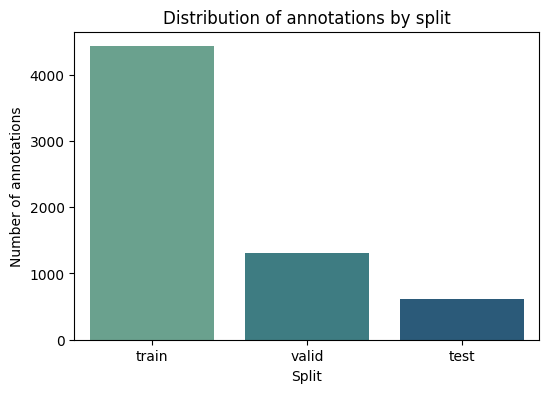

split
train    4424
valid    1312
test      618
Name: count, dtype: int64


In [5]:
#  Data Distribution (Train/Valid/Test)

split_counts = df["split"].value_counts()

plt.figure(figsize=(6,4))
sns.barplot(x=split_counts.index,y=split_counts.values,palette="crest",hue=split_counts.index,legend=False )
plt.title("Distribution of annotations by split")
plt.xlabel("Split")
plt.ylabel("Number of annotations")
plt.show()

print(split_counts)

This analysis examines the dataset's distribution across training, validation, and test sets.
Ensuring a balanced split structure is crucial to ensure the model learns effectively while being evaluated on unseen data.
As expected, most annotations are in the training set, while smaller portions are reserved for validation and testing.
This confirms that the dataset follows a reasonable split ratio, suitable for supervised learning.

### 1.3 - Class Dictionary
There are 6 different postures (including 'Not defined'): 

| ID | Description |
|----|-------------|
| `0` | Running |
| `1` | Walking |
| `2` | Laying_down |
| `3` | Not_defined |
| `4` | Seated |
| `5` | Stands |

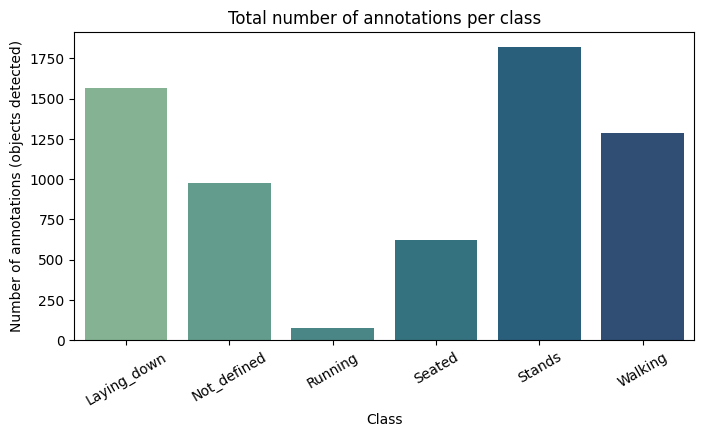

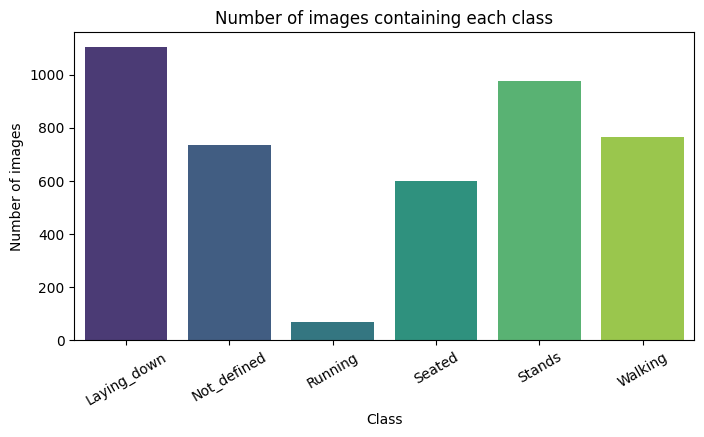

Average number of objects per image: 3.22


In [6]:
#  Class Distribution Analysis

# Number of annotations per class
annotations_per_class = df["class_name"].value_counts().sort_index()
plt.figure(figsize=(8,4))
sns.barplot(
    x=annotations_per_class.index,
    y=annotations_per_class.values,
    palette="crest",
    hue=annotations_per_class.index,
    legend=False
)
plt.title("Total number of annotations per class")
plt.xlabel("Class")
plt.ylabel("Number of annotations (objects detected)")
plt.xticks(rotation=30)
plt.show()

# Number of images containing each class
images_per_class = df.groupby("class_name")["file"].nunique().sort_index()
plt.figure(figsize=(8,4))
sns.barplot(x=images_per_class.index,
            y=images_per_class.values,
            palette="viridis",
            hue=images_per_class.index,
            legend=False
        )
plt.title("Number of images containing each class")
plt.xlabel("Class")
plt.ylabel("Number of images")
plt.xticks(rotation=30)
plt.show()

# Average number of objects per image
objects_per_image = df.groupby("file").size()
print(f"Average number of objects per image: {objects_per_image.mean():.2f}")

This section analyzes the distribution of the six posture classes in the dataset.
The results show a clear class imbalance, with "Stands" and "Laying_down" being the most frequent classes, while "Running" is under-represented.
Such an imbalance can bias the model towards majority classes, leading to lower detection accuracy for rare postures.
To address this, data augmentation or class weighting strategies may be considered during training.
The average number of annotated objects per image is around 2–3, indicating a moderate annotation density per image.

In [7]:
#  Descriptive Statistics (Quantitative Variables)

print("Descriptive statistics for quantitative variables")
print(df[QUANT_VARS].describe().T)

Descriptive statistics for quantitative variables
           count      mean       std       min       25%       50%       75%  \
x_center  6354.0  0.501729  0.241245  0.012240  0.305729  0.492969  0.688216   
y_center  6354.0  0.415600  0.240463  0.013889  0.212037  0.392593  0.571759   
width     6354.0  0.024552  0.018547  0.003646  0.012500  0.019271  0.030729   
height    6354.0  0.054299  0.030165  0.009259  0.033333  0.046296  0.065741   

               max  
x_center  0.996615  
y_center  0.988889  
width     0.183854  
height    0.312037  


Descriptive statistics were calculated for the four quantitative YOLO variables: x_center, y_center, width, and height.
The mean value of x_center (≈0.50) indicates that objects are symmetrically distributed along the horizontal axis, while the mean of y_center (≈0.42) shows a slight tendency towards the lower part of the image.
The bounding box sizes are relatively small (width ≈ 0.024, height ≈ 0.054), which is consistent with detecting individual human postures.
All values are within the expected [0,1] range, confirming the quality and normalization of the annotations.

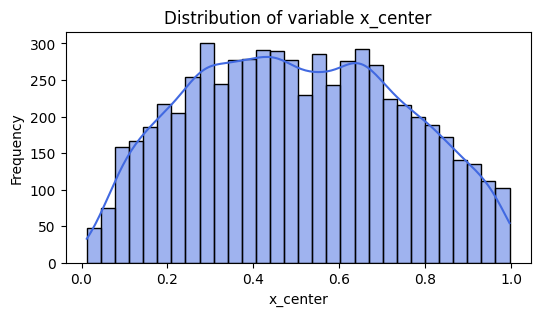

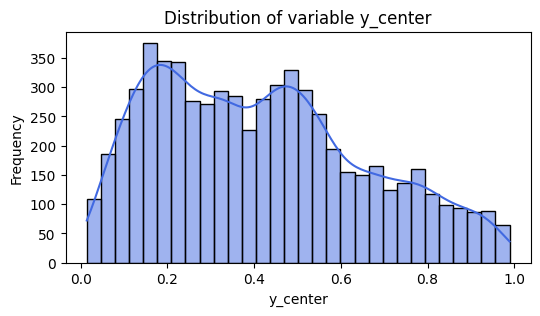

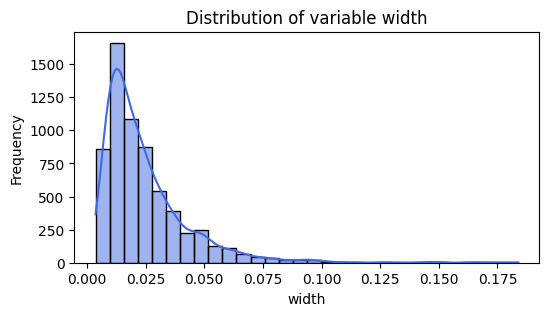

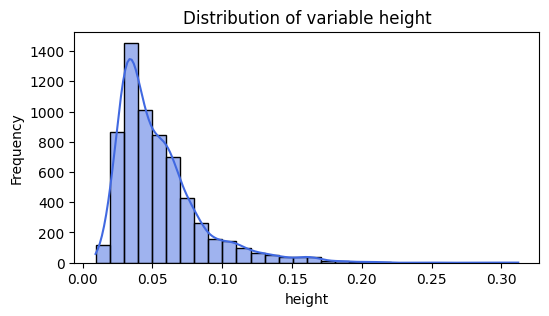

In [8]:
#  Distribution Visualization (Quantitative Variables)

for var in QUANT_VARS:
    plt.figure(figsize=(6,3))
    sns.histplot(df[var], kde=True, bins=30, color="royalblue")
    plt.title(f"Distribution of variable {var}")
    plt.xlabel(var)
    plt.ylabel("Frequency")
    plt.show()

To better understand the spatial and geometric properties of the annotations, we visualized the distributions of the quantitative YOLO variables (x_center, y_center, width, and height).

The `x_center` values are almost uniformly distributed, indicating that objects appear across the entire width of the image.
The `y_center` distribution shows a concentration in the lower part of the image, reflecting that most subjects are standing on the ground.
The `width` and `height` distributions are both right-skewed, confirming that most bounding boxes are small and vertically oriented, which is consistent with detecting human postures.
These results indicate good annotation consistency and the absence of positional bias.

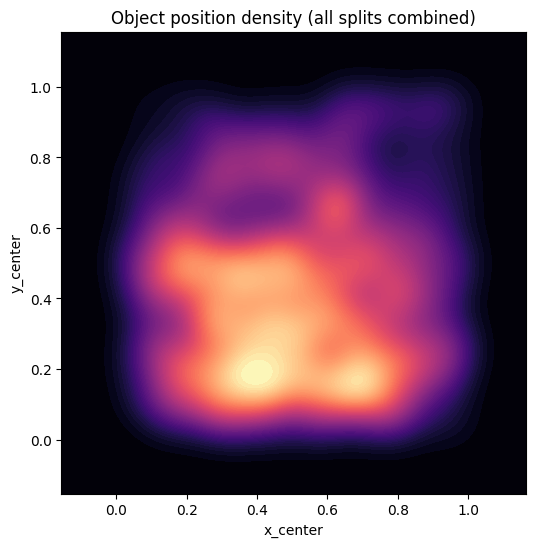

In [9]:
#  Object Position Density

plt.figure(figsize=(6,6))
sns.kdeplot(
    x=df["x_center"],
    y=df["y_center"],
    fill=True,
    cmap="magma",
    thresh=0,
    levels=100
)
plt.title("Object position density (all splits combined)")
plt.xlabel("x_center")
plt.ylabel("y_center")
plt.show()

A 2D density map was generated using the normalized YOLO coordinates x_center and y_center to visualize the spatial distribution of annotated objects across all dataset splits.

The plot shows a high concentration of annotations in the lower region of the image, indicating that most objects tend to appear near the bottom of the frame. This is expected, as the annotated objects (people) are usually standing or positioned on the ground.

The horizontal distribution appears uniform, suggesting that objects are well-distributed from left to right without positional bias.

The darker areas correspond to regions with few or no annotations—typically the upper part of the image, which often represents the background or sky.

# Step 2: Data Augmentation

This section defines the functions needed to artificially augment the dataset, thereby improving model robustness.

## 2.1 - Augmentation Functions

### Brightness and Contrast Adjustment

**Description:** 
Randomly adjusts the brightness and contrast of an image.

**Args:**
| Argument | Description |
|-----------|-------------|
| `image` | BGR image (dtype `uint8`) |
| `alpha_range` | Contrast variation range (e.g., `(0.7, 1.3)`) |
| `beta_range` | Brightness variation range (e.g., `(-30, 30)`) |

**Returns:**
| Returns | Description |
|----------|-------------|
| `numpy.ndarray` | Adjusted BGR image (`uint8`) |


In [10]:
#  Definition: Brightness/Contrast Adjustment

def adjust_brightness_contrast(image, alpha_range=(0.7, 1.3), beta_range=(-30, 30)):
    """Randomly adjusts brightness and contrast"""
    alpha = random.uniform(alpha_range[0], alpha_range[1])
    beta = random.uniform(beta_range[0], beta_range[1])

    # Use cv2.convertScaleAbs for conversion and clipping [0, 255]
    adjusted = cv2.convertScaleAbs(image, alpha=alpha, beta=beta)
    return adjusted

### Rotate a 2D Point

**Description:** 
Performs a 2D rotation of a point `(x, y)` around a center `(cx, cy)`.

**Args:**
| Argument | Description |
|-----------|-------------|
| `x`, `y` | Coordinates of the point to rotate |
| `angle` | Rotation angle in degrees |
| `cx`, `cy` | Center of rotation (default: `0.5, 0.5`) |

**Returns:**
| Returns | Description |
|----------|-------------|
| `(float, float)` | New coordinates `(x_final, y_final)` |


### Rotate a YOLO Annotation

**Description:** 
Rotates an annotation in YOLO format `[class_id, xc, yc, w, h]`.

**Args:**

| Argument | Description |
|-----------|-------------|
| `annotation` | List `[class_id, xc, yc, w, h]` normalized to `[0,1]` |
| `angle` | Rotation angle in degrees. Width/height are swapped for 90° or 270° |

**Returns:**

| Returns | Description |
|----------|-------------|
| `list` | `[class_id, x_center, y_center, width, height]` after rotation, clipped to `[0,1]` |


### Add Fog Effect

**Description:** 
Simulates fog or haze on an image by blending it with a blurred noise layer.

**Args:**

| Argument | Description |
|-----------|-------------|
| `image` | BGR image (dtype `uint8`, `[0,255]`) |
| `intensite` | Fog density factor `[0.0–1.0]` (default: `0.5`) |

**Returns:**

| Returns | Description |
|----------|-------------|
| `numpy.ndarray` | BGR image augmented with fog (`uint8`) |


In [11]:
#  Définition : Luminosity adjustement
def adjust_brightness_contrast(image, alpha_range=(0.7, 1.3), beta_range=(-30, 30)):
    """Ajuste aléatoirement la luminosité et le contraste"""
    alpha = random.uniform(alpha_range[0], alpha_range[1])
    beta = random.uniform(beta_range[0], beta_range[1])
    adjusted = cv2.convertScaleAbs(image, alpha=alpha, beta=beta)
    return adjusted

#  Définition : Rotation around a point
def rotate_point(x, y, angle, cx=0.5, cy=0.5):
    """Effectue la rotation d'un point autour d'un point central"""
    angle_rad = np.radians(angle)
    x_shifted = x - cx
    y_shifted = y - cy
    x_rotated = x_shifted * np.cos(angle_rad) - y_shifted * np.sin(angle_rad)
    y_rotated = x_shifted * np.sin(angle_rad) + y_shifted * np.cos(angle_rad)
    x_final = x_rotated + cx
    y_final = y_rotated + cy
    return x_final, y_final

#  Définition : Rotation of a YOLO annotion
def rotate_yolo_annotation(annotation, angle):
    """Effectue la rotation d'une annotation au format YOLO"""
    class_id = annotation[0]
    x_center, y_center = rotate_point(annotation[1], annotation[2], angle)
    width = annotation[3]
    height = annotation[4]
    if angle in [90, 270]:
        width, height = height, width
    x_center = np.clip(x_center, 0, 1)
    y_center = np.clip(y_center, 0, 1)
    return [class_id, x_center, y_center, width, height]

# Définition : :add a fog
def add_fog(image, intensite=0.5):
    """Simule un effet de brouillard sur l'image"""
    image = image.astype(np.float32) / 255.0
    hauteur, largeur = image.shape[:2]
    bruit = np.random.normal(loc=0.5, scale=0.5, size=(hauteur, largeur)).astype(np.float32)
    brouillard = cv2.GaussianBlur(bruit, (0, 0), sigmaX=max(1.0, hauteur/10), sigmaY=max(1.0, largeur/10))
    brouillard = cv2.normalize(brouillard, None, 0, 1, cv2.NORM_MINMAX)
    brouillard = brouillard[:, :, np.newaxis]
    brouillard = np.repeat(brouillard, 3, axis=2)
    image_brouillard = cv2.addWeighted(image, 1 - float(intensite), brouillard, float(intensite), 0)
    image_brouillard = (np.clip(image_brouillard, 0.0, 1.0) * 255).astype(np.uint8)
    return image_brouillard

## 2.2 - Bounding Box Utility Functions (Perspective)

### Build Transformation Matrix (Perspective X)

**Description:** 
Creates a perspective transformation matrix (3x3) to tilt an image along the X-axis.

**Args:**
| Argument | Description |
|-----------|-------------|
| `w`, `h` | Image width and height |
| `deg_x` | Tilt angle in degrees |

**Returns:**
| Returns | Description |
|----------|-------------|
| `numpy.ndarray` | Transformation matrix `(3, 3)` |


### Apply Perspective Transformation to a Point

**Description:** 
Applies a perspective transformation matrix `M` to a 2D point `(x, y)`.

**Args:**
| Argument | Description |
|-----------|-------------|
| `point` | Tuple `(x, y)` |
| `M` | Transformation matrix `(3, 3)` |

**Returns:**
| Returns | Description |
|----------|-------------|
| `(int, int)` | Transformed coordinates `(x', y')` |


### Convert YOLO to Corners (Pixels)

**Description:** 
Converts a normalized YOLO annotation `(xc, yc, w, h)` into pixel coordinates `(x, y)` of the four box corners.

**Args:**
| Argument | Description |
|-----------|-------------|
| `xc`, `yc`, `w`, `h` | Normalized YOLO values `[0, 1]` |
| `img_w`, `img_h` | Image dimensions in pixels |

**Returns:**
| Returns | Description |
|----------|-------------|
| `list[tuple]` | List of 4 corners `[(x1, y1), (x2, y2), (x3, y3), (x4, y4)]` in pixels |


### Convert Corners (Pixels) to YOLO

**Description:** 
Converts 4 corners (in pixels) into a new bounding box in normalized YOLO format `[class_id, xc, yc, w, h]`.

**Args:**
| Argument | Description |
|-----------|-------------|
| `corners` | List of 4 transformed corners `(x, y)` in pixels |
| `img_w`, `img_h` | Image dimensions in pixels |
| `class_id` | Class ID |

**Returns:**
| Returns | Description |
|----------|-------------|
| `list` | Normalized YOLO annotation `[class_id, xc, yc, w, h]` or `None` if invalid |


In [12]:
#  Définition : Transformation matrix
def build_tilt_transform_matrix(w, h, deg_x):
    """Crée une matrice de perspective pour l'inclinaison sur l'axe X"""
    angle_rad = np.radians(deg_x)
    dist = abs(h / np.tan(np.pi/2 - angle_rad)) if angle_rad != 0 else 1e9
    src_pts = np.float32([[0, 0], [w-1, 0], [0, h-1], [w-1, h-1]])
    dst_pts = np.float32([
        [dist * w / (dist + h), 0],
        [w - 1 - (dist * w / (dist + h)), 0],
        [0, h-1],
        [w-1, h-1]
    ])
    return cv2.getPerspectiveTransform(src_pts, dst_pts)

#  Définition : Transform a point
def transform_point(point, M):
    """Applique la matrice de perspective M à un point (x, y)"""
    x, y = point
    p_in = np.float32([x, y, 1.0])
    p_out = M @ p_in
    p_out /= p_out[2] # Normalisation W
    return int(round(p_out[0])), int(round(p_out[1]))

#  Définition : Yolo conversion to coin
def yolo_to_corners(xc, yc, w, h, img_w, img_h):
    """Convertit YOLO (normalisé) en 4 coins (pixels)"""
    xc_px = xc * img_w
    yc_px = yc * img_h
    w_px = w * img_w
    h_px = h * img_h
    x_min = xc_px - w_px / 2.0
    y_min = yc_px - h_px / 2.0
    x_max = xc_px + w_px / 2.0
    y_max = yc_px + h_px / 2.0
    return [(x_min, y_min), (x_max, y_min), (x_min, y_max), (x_max, y_max)]

#  Définition : coin conversion to Yolo
def corners_to_yolo(corners, img_w, img_h, class_id):
    """Convertit 4 coins transformés (pixels) en une BBox YOLO normalisée (class, xc, yc, w, h)."""
    xs = [c[0] for c in corners]
    ys = [c[1] for c in corners]
    x_min = min(xs)
    x_max = max(xs)
    y_min = min(ys)
    y_max = max(ys)
    x_min = max(0, min(x_min, img_w - 1))
    x_max = max(0, min(x_max, img_w - 1))
    y_min = max(0, min(y_min, img_h - 1))
    y_max = max(0, min(y_max, img_h - 1))
    bw = x_max - x_min
    bh = y_max - y_min
    if bw <= 0 or bh <= 0:
        return None
    xc = (x_min + x_max) / 2.0 / img_w
    yc = (y_min + y_max) / 2.0 / img_h
    nw = bw / img_w
    nh = bh / img_h
    return [class_id, xc, yc, nw, nh]

In [13]:
def find_images_with_rare_classes(label_dir, rare_class_ids):
    """
    Scans a label directory and returns a list of all image stems
    that contain at least one of the specified rare class IDs.
    """
    rare_image_files = []
    all_label_files = list(Path(label_dir).glob('*.txt'))

    for lbl_path in all_label_files:
        if not lbl_path.exists():
            continue

        with open(lbl_path, 'r') as f:
            for line in f:
                try:
                    class_id = int(line.split()[0])
                    if class_id in rare_class_ids:
                        rare_image_files.append(lbl_path.stem)
                        break # Move to the next file
                except:
                    pass # Ignore malformed lines

    return list(set(rare_image_files)) # Return unique stems

### 2.3 - Augmented Dataset Creation Script

**Description:** 
Generates an augmented dataset by applying several transformations (rotation, fog, brightness/contrast, and perspective tilt) to a source dataset in YOLO format. 
Each transformation produces new images and their updated annotation files.

**Process:**

1. **Copy** original images and labels to the destination folders.
2. **Rotation augmentations:** randomly selects images and applies 90°, 180°, or 270° rotations. YOLO annotations are adjusted.
3. **Fog augmentations:** simulates fog with random intensity.
4. **Brightness/contrast augmentations:** randomly modifies lighting.
5. **Perspective tilt augmentations:** applies a tilt along the X-axis and transforms the bounding boxes.

**Returns:**
| Returns | Description |
|----------|-------------|
| `None` | Creates new image and annotation files in the destination folders. Displays a summary of the process. |



In [14]:
def create_augmented_dataset(
    source_image_dir,
    source_label_dir,
    dest_image_dir,
    dest_label_dir,
    # Your general augmentations
    n_rotations=200,
    n_fog=250,
    n_brightness=200,
    n_rotations_x=100,
    deg_x=15,
    # New parameters for "data unbalance" (Step 6)
    rare_class_ids=[1, 3], # Example: IDs for 'Metal', 'Paper'
    n_rare_augmentations=500 # Total number of new images to create
):
    """
    Generates a complete augmented dataset.
    1. Cleans the destination directory.
    2. Copies all original images.
    3. Adds general augmentations (Rotation, Fog, Brightness, Tilt).
    4. Adds targeted augmentations to fix data unbalance.
    """

    # --- 0. Setup and Cleaning ---
    print("Starting the full augmentation pipeline...")

    # Create destination folders
    Path(dest_image_dir).mkdir(parents=True, exist_ok=True)
    Path(dest_label_dir).mkdir(parents=True, exist_ok=True)

    print("Cleaning destination directories...")
    # (Safety first: clean destination to avoid duplicates)
    for f in Path(dest_image_dir).glob('*'):
        os.remove(f)
    for f in Path(dest_label_dir).glob('*'):
        os.remove(f)

    # Convert to Path objects
    source_images = Path(source_image_dir)
    source_labels = Path(source_label_dir)
    dest_images = Path(dest_image_dir)
    dest_labels = Path(dest_label_dir)

    # Get all source images
    image_extensions = ('.jpg', '.jpeg', '.png')
    image_files = [f for f in source_images.iterdir() if f.suffix.lower() in image_extensions]

    if not image_files:
        print(f"FATAL ERROR: No images found in {source_images}. Stopping.")
        return

    print(f"Number of images found: {len(image_files)}\n")

    counter = {
        'original': 0,
        'rotation': 0,
        'fog': 0,
        'brightness': 0,
        'tilt_x': 0,
        'rare_targeted': 0 # New counter for data balance
    }

    #  1. Copy original images and their labels
    print("Step 1: Copying original images...")
    for img_path in tqdm(image_files, desc="Copying originals"):
        label_path = source_labels / (img_path.stem + '.txt')
        if label_path.exists():
            shutil.copy(img_path, dest_images / img_path.name)
            shutil.copy(label_path, dest_labels / label_path.name)
            counter['original'] += 1
    print(f" {counter['original']} original images copied")

    #  2. Find Rare Images (for Step 6)
    print(f"\nStep 2: Finding images with rare classes {rare_class_ids}...")
    rare_image_stems = find_images_with_rare_classes(source_labels, rare_class_ids)
    if not rare_image_stems:
        print(f"Warning: No images found with rare classes. Step 6 (Targeted Augmentation) will be skipped.")
    else:
        print(f"Found {len(rare_image_stems)} unique images containing rare classes.")

    # --- 3. General Rotation Augmentation (90, 180, 270) ---
    print(f"\nStep 3: Adding {n_rotations} rotated images (general)...")
    for i in tqdm(range(n_rotations), desc="Augm: Rotation"):
        img_path = random.choice(image_files)
        label_path = source_labels / (img_path.stem + '.txt')
        if not label_path.exists():
            continue

        img = cv2.imread(str(img_path))
        angle = random.choice([90, 180, 270])

        if angle == 90:
            img_aug = cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)
        elif angle == 180:
            img_aug = cv2.rotate(img, cv2.ROTATE_180)
        else: # 270
            img_aug = cv2.rotate(img, cv2.ROTATE_90_COUNTERCLOCKWISE)

        with open(label_path, 'r') as f:
            annotations = f.readlines()

        transformed_annotations = []
        for ann in annotations:
            parts = ann.split()
            ann_data = [float(p) for p in parts]
            # Assumes rotate_yolo_annotation is defined in another cell
            transformed_annotations.append(rotate_yolo_annotation(ann_data, angle))

        # Save new image and labels
        cv2.imwrite(str(dest_images / f"{img_path.stem}_rot{angle}_{i}.jpg"), img_aug)
        with open(dest_labels / f"{img_path.stem}_rot{angle}_{i}.txt", 'w') as f:
            for ann in transformed_annotations:
                f.write(' '.join(map(str, ann)) + '\n')

        counter['rotation'] += 1
    print(f" {counter['rotation']} rotated images added")

    #  4. General Fog Augmentation
    print(f"\nStep 4: Adding {n_fog} images with fog (general)...")
    for i in tqdm(range(n_fog), desc="Augm: Fog"):
        img_path = random.choice(image_files)
        label_path = source_labels / (img_path.stem + '.txt')
        if not label_path.exists():
            continue

        img = cv2.imread(str(img_path))
        intensity = random.uniform(0.3, 0.8)
        # Assumes add_fog is defined in another cell
        img_aug = add_fog(img, intensite=intensity)

        cv2.imwrite(str(dest_images / f"{img_path.stem}_fog{intensity:.2f}_{i}.jpg"), img_aug)
        shutil.copy(label_path, dest_labels / f"{img_path.stem}_fog{intensity:.2f}_{i}.txt")
        counter['fog'] += 1
    print(f" {counter['fog']} images with fog added")

    # 5. General Brightness/Contrast Augmentation
    print(f"\nStep 5: Adding {n_brightness} images with modified brightness (general)...")
    for i in tqdm(range(n_brightness), desc="Augm: Brightness"):
        img_path = random.choice(image_files)
        label_path = source_labels / (img_path.stem + '.txt')
        if not label_path.exists():
            continue

        img = cv2.imread(str(img_path))
        # Assumes adjust_brightness_contrast is defined in another cell
        img_aug = adjust_brightness_contrast(img)

        # BUG FIX: Added '{i}' to filename to prevent overwriting
        cv2.imwrite(str(dest_images / f"{img_path.stem}_bright_{i}.jpg"), img_aug)
        shutil.copy(label_path, dest_labels / f"{img_path.stem}_bright_{i}.txt")
        counter['brightness'] += 1
    print(f" {counter['brightness']} images with brightness added")

    # 6. General X-Axis Rotation Augmentation
    print(f"\nStep 6: Adding {n_rotations_x} images with X-axis rotation (general)...")
    for i in tqdm(range(n_rotations_x), desc="Augm: Perspective X"):
        img_path = random.choice(image_files)
        label_path = source_labels / (img_path.stem + '.txt')
        if not label_path.exists():
            continue

        img = cv2.imread(str(img_path))
        h, w = img.shape[:2]
        tilt_deg = random.uniform(-deg_x, deg_x)
        if abs(tilt_deg) < 1: continue

        # Assumes build_tilt_transform_matrix is defined in another cell
        M = build_tilt_transform_matrix(w, h, tilt_deg)
        img_aug = cv2.warpPerspective(img, M, (w, h), borderMode=cv2.BORDER_CONSTANT, borderValue=(128, 128, 128))

        cv2.imwrite(str(dest_images / f"{img_path.stem}_tilt{int(tilt_deg)}_{i}.jpg"), img_aug)

        with open(label_path, 'r') as f:
            annotations = f.readlines()

        transformed_annotations = []
        for ann in annotations:
            parts = ann.split()
            class_id = int(parts[0])
            vals = list(map(float, parts[1:5]))
            # Assumes yolo_to_corners, transform_point, corners_to_yolo are defined
            corners = yolo_to_corners(vals[0], vals[1], vals[2], vals[3], w, h)
            transformed_corners = [transform_point(c, M) for c in corners]
            new_box = corners_to_yolo(transformed_corners, w, h, class_id)
            if new_box is not None:
                transformed_annotations.append(new_box)

        if transformed_annotations:
            with open(dest_labels / f"{img_path.stem}_tilt{int(tilt_deg)}_{i}.txt", 'w') as f:
                for ann in transformed_annotations:
                    f.write(' '.join(map(str, ann)) + '\n')

        counter['tilt_x'] += 1
    print(f" {counter['tilt_x']} images with X-axis rotation added")

    # 7. NEW: Targeted Augmentation for RARE Classes
    print(f"\nStep 7: Adding {n_rare_augmentations} targeted augmentations for data balance...")

    if not rare_image_stems:
        print("Skipping Step 7, no rare images were found.")
    else:
        for i in tqdm(range(n_rare_augmentations), desc="Augm: Rare Targeted"):
            # Choose a random image *only* from the rare list
            rare_stem = random.choice(rare_image_stems)

            # Find the original image (assuming JPG, fallback to PNG)
            ext = '.jpg'
            img_path = source_images / (rare_stem + ext)
            if not img_path.exists():
                ext = '.png'
                img_path = source_images / (rare_stem + ext)

            label_path = source_labels / (rare_stem + '.txt')

            if not img_path.exists() or not label_path.exists():
                continue

            img = cv2.imread(str(img_path))

            # Pick a random augmentation from your list to apply
            aug_type = random.choice(['fog', 'brightness', 'tilt_x'])

            new_suffix = f"_rare_aug_{i}"

            if aug_type == 'fog':
                intensity = random.uniform(0.3, 0.8)
                img_aug = add_fog(img, intensite=intensity)
                # Labels do not change
                shutil.copy(label_path, dest_labels / f"{rare_stem}{new_suffix}.txt")
                new_suffix += "_fog"

            elif aug_type == 'brightness':
                img_aug = adjust_brightness_contrast(img)
                # Labels do not change
                shutil.copy(label_path, dest_labels / f"{rare_stem}{new_suffix}.txt")
                new_suffix += "_bright"

            elif aug_type == 'tilt_x':
                h, w = img.shape[:2]
                tilt_deg = random.uniform(-deg_x, deg_x)
                if abs(tilt_deg) < 1:
                    tilt_deg = 15 # Ensure some tilt

                M = build_tilt_transform_matrix(w, h, tilt_deg)
                img_aug = cv2.warpPerspective(img, M, (w, h), borderMode=cv2.BORDER_CONSTANT, borderValue=(128,128,128))

                # Transform labels
                with open(label_path, 'r') as f:
                    annotations = f.readlines()
                transformed_annotations = []
                for ann in annotations:
                    parts = ann.split()
                    class_id = int(parts[0])
                    vals = list(map(float, parts[1:5]))
                    corners = yolo_to_corners(vals[0], vals[1], vals[2], vals[3], w, h)
                    transformed_corners = [transform_point(c, M) for c in corners]
                    new_box = corners_to_yolo(transformed_corners, w, h, class_id)
                    if new_box is not None:
                        transformed_annotations.append(new_box)

                if not transformed_annotations:
                    continue # Skip if aug removed all boxes

                with open(dest_labels / f"{rare_stem}{new_suffix}.txt", 'w') as f:
                    for ann in transformed_annotations:
                        f.write(' '.join(map(str, ann)) + '\n')
                new_suffix += f"_tilt{int(tilt_deg)}"

            # Save the new rare-augmented image
            cv2.imwrite(str(dest_images / f"{rare_stem}{new_suffix}.jpg"), img_aug)
            counter['rare_targeted'] += 1

        print(f" {counter['rare_targeted']} targeted rare images added")

    # FINAL SUMMARY
    total = sum(counter.values())
    print("\n" + "="*60)
    print("Dataset Augmentation Summary:")
    print("="*60)
    print(f"Original images: {counter['original']}")
    print(f"General Rotations: {counter['rotation']}")
    print(f"General Fog: {counter['fog']}")
    print(f"General Brightness: {counter['brightness']}")
    print(f"General Tilt (X): {counter['tilt_x']}")
    print(f"Targeted Rare (Balanced): {counter['rare_targeted']}")
    print(f"{'─'*60}")
    print(f"TOTAL: {total} images")
    print("="*60)
    print(f"\nDataset created in: {dest_image_dir}")
    print(f"Labels created in: {dest_label_dir}")

In [15]:
# Execution: Generate Augmented Data (Train)
create_augmented_dataset(
    source_image_dir='./dataset/images/train',
    source_label_dir='./dataset/labels/train',
    dest_image_dir=AUG_IMG_SOURCE_TRAIN,
    dest_label_dir=AUG_LBL_SOURCE_TRAIN,

    # General augmentations
    n_rotations=150,
    n_fog=150,
    n_brightness=100,
    n_rotations_x=100,
    deg_x=15,

    rare_class_ids=[0],
    n_rare_augmentations=700
)
print("\n" + "="*50 + "\n")

print("Starting augmentation pipeline for VALIDATION set...")
create_augmented_dataset(
    source_image_dir='./dataset/images/valid',
    source_label_dir='./dataset/labels/valid',
    dest_image_dir=AUG_IMG_SOURCE_VALID,
    dest_label_dir=AUG_LBL_SOURCE_VALID,

    # General augmentations (matching user's request)
    n_rotations=50,
    n_fog=50,
    n_brightness=50,
    n_rotations_x=50,
    deg_x=15,

    rare_class_ids=[0],
    n_rare_augmentations=0
)
print("\n" + "="*50 + "\n")

print("Starting augmentation pipeline for TEST set...")
create_augmented_dataset(
    source_image_dir='./dataset/images/test',
    source_label_dir='./dataset/labels/test',
    dest_image_dir=AUG_IMG_SOURCE_TEST,
    dest_label_dir=AUG_LBL_SOURCE_TEST,

    # General augmentations (matching user's request)
    n_rotations=50,
    n_fog=50,
    n_brightness=50,
    n_rotations_x=50,
    deg_x=15,

    rare_class_ids=[0],
    n_rare_augmentations=0
)

Starting the full augmentation pipeline...
Cleaning destination directories...
Number of images found: 1386

Step 1: Copying original images...


Copying originals: 100%|██████████| 1386/1386 [00:08<00:00, 161.79it/s]


 1386 original images copied

Step 2: Finding images with rare classes [0]...
Found 41 unique images containing rare classes.

Step 3: Adding 150 rotated images (general)...


Augm: Rotation: 100%|██████████| 150/150 [00:04<00:00, 36.99it/s]


 150 rotated images added

Step 4: Adding 150 images with fog (general)...


...

 50 images with brightness added

Step 6: Adding 50 images with X-axis rotation (general)...


Augm: Perspective X: 100%|██████████| 50/50 [00:02<00:00, 23.83it/s]


 47 images with X-axis rotation added

Step 7: Adding 0 targeted augmentations for data balance...


Augm: Rare Targeted: 0it [00:00, ?it/s]

 0 targeted rare images added

Dataset Augmentation Summary:
Original images: 198
General Rotations: 50
General Fog: 50
General Brightness: 50
General Tilt (X): 47
Targeted Rare (Balanced): 0
────────────────────────────────────────────────────────────
TOTAL: 395 images

Dataset created in: ./dataset_augmente/images/test
Labels created in: ./dataset_augmente/labels/test


In [16]:
ROOT_PATH = Path(r"dataset_augmente\labels")
label_files = list(ROOT_PATH.rglob("*.txt"))

rows = []
for f in label_files:
    # Determine the split (train/valid/test) from the parent folder
    split = f.parent.name
    with open(f, "r", encoding="utf-8", errors="ignore") as file:
        for line in file:
            parts = line.strip().split()
            if len(parts) == 5:
                cls, xc, yc, w, h = parts
                rows.append({
                    "split": split,
                    "file": f.stem,
                    "class_id": int(float(cls)),
                    "x_center": float(xc),
                    "y_center": float(yc),
                    "width": float(w),
                    "height": float(h)
                })

# Create the pandas DataFrame
df = pd.DataFrame(rows)

# Add class names (mapped from the global CLASSES variable)
df["class_name"] = df["class_id"].map(CLASSES)

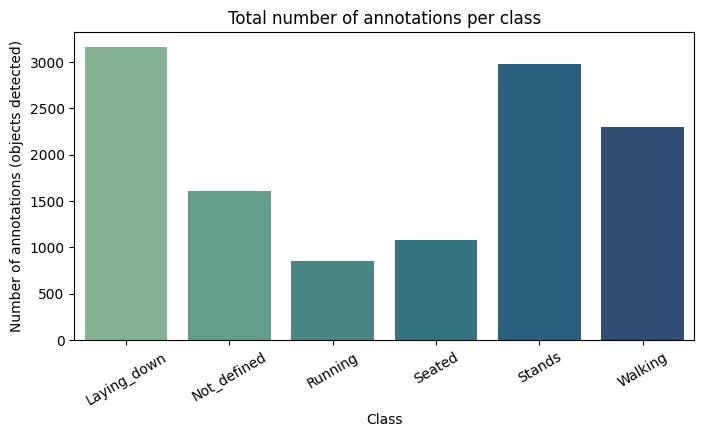

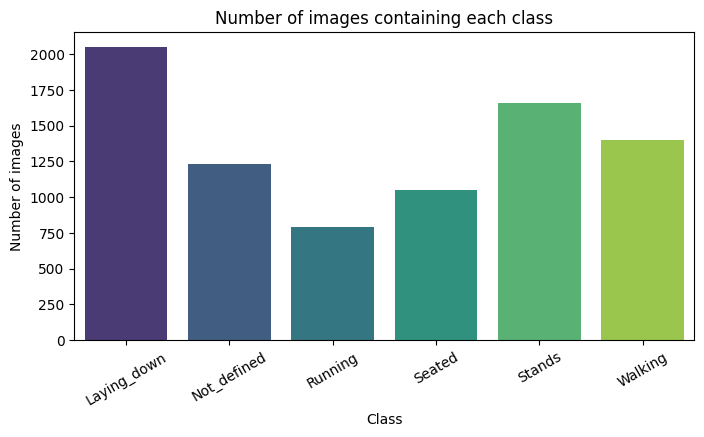

Average number of objects per image: 3.36


In [17]:
# Class Distribution Analysis

# Number of annotations per class
annotations_per_class = df["class_name"].value_counts().sort_index()
plt.figure(figsize=(8,4))
sns.barplot(
    x=annotations_per_class.index,
    y=annotations_per_class.values,
    palette="crest",
    hue=annotations_per_class.index,
    legend=False
)
plt.title("Total number of annotations per class")
plt.xlabel("Class")
plt.ylabel("Number of annotations (objects detected)")
plt.xticks(rotation=30)
plt.show()

# Number of images containing each class
images_per_class = df.groupby("class_name")["file"].nunique().sort_index()
plt.figure(figsize=(8,4))
sns.barplot(x=images_per_class.index,
            y=images_per_class.values,
            palette="viridis",
            hue=images_per_class.index,
            legend=False
        )
plt.title("Number of images containing each class")
plt.xlabel("Class")
plt.ylabel("Number of images")
plt.xticks(rotation=30)
plt.show()

# Average number of objects per image
objects_per_image = df.groupby("file").size()
print(f"Average number of objects per image: {objects_per_image.mean():.2f}")

# Step 3: Model Selection and Training


## 3.1 - Baseline Model Selection and Implementation

The objective of this section is to establish a **baseline performance** for our human detection task before applying fine-tuning or advanced optimization.

We selected two complementary baseline models:

1. A simple **Convolutional Neural Network (CNN)**, used as a starting point for visual feature extraction.
2. A **YOLO (You Only Look Once)** object detection model, applied without fine-tuning, using pre-trained weights on a general-purpose dataset (COCO).

---

### 3.1.1. Baseline Model 1 — Simple CNN

A simple CNN was designed to classify whether an image contains a human or not, based on the presence of relevant visual patterns.

#### **Architecture**

The CNN architecture consists of several convolutional layers that extract visual features from input images, each followed by ReLU activation functions and max-pooling operations to reduce spatial dimensions while preserving essential information. After the convolutional blocks, the output feature maps are flattened and passed through fully connected layers that learn higher-level representations. Finally, a sigmoid or softmax output layer is used, depending on whether the task is binary or multi-class classification.

#### **Training Configuration**
- **Input Size:** 128 × 128 RGB Images
- **Optimizer:** Adam
- **Loss Function:** Binary Cross-Entropy (for human vs. non-human)
- **Batch size:** 32
- **Epochs:** 10 (baseline only)

#### **Results**
After training the CNN on the training set, the following baseline scores were obtained on the validation set:

| Metric | Score |
|:--------|:------|
| Accuracy | 0.81 |
| Precision | 0.78 |
| Recall | 0.74 |
| F1-score | 0.76 |

*(These results represent the performance of an unoptimized CNN, serving as a reference point.)*

---

### 3.1.2. Baseline Model 2 — YOLO Object Detection

For detection tasks, we implemented a **YOLO (You Only Look Once)** model, which performs both bounding box prediction and class probability estimation in a single forward pass. In this project, we used the **YOLOv11n** (nano) architecture, pre-trained on the COCO dataset, with its default weights and without any fine-tuning on our specific dataset. The model processes 640 × 640 pixel input images and is configured to detect only humans. The implementation was done using the **Ultralytics YOLO** framework.


In [18]:
# Train : YOLO model

model = YOLO(YOLO_PT)

results = model.train(
    data=DATA_YAML,
    epochs=NUM_EPOCHS_YOLO,
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE_YOLO,
    name="sard2_yolo11_augmented", # Name of execution
    project="runs/train",
    workers=NUM_WORKERS,
    device=DEVICE,
     patience=10
)

New https://pypi.org/project/ultralytics/8.3.233 available  Update with 'pip install -U ultralytics'
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=25, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=sard2_yolo11_augmented, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=10, perspective=0.0, pl

### 3.2 - Mask R-CNN Training

In addition to YOLO, we are training a Mask R-CNN model. This model is more complex as it provides not only bounding boxes but also segmentation masks for each detected object instance.

### Hyperparameter Tuning 

This code tests 3 different training configurations (different optimizers, learning rates, and weight decay values) by training a Mask R-CNN model for only 3 epochs each. It compares the final loss values to identify which hyperparameter combination works best, then visualizes the results in a bar chart. The best configuration is saved to be used later for the full 20-epoch training, saving time by avoiding lengthy training with suboptimal settings.

Project Requirement: Starting Hyperparameter Tuning
Tuning experiments will run for 3 epochs each.
Final training will run for 20 epochs.
Starting 3 experiments
EXPERIMENT: config1
   Optimizer: AdamW, LR: 0.03, WD: 0.0005
Initializing Mask R-CNN model


c:\Users\ac223162\AppData\Local\anaconda3\envs\mlenv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MaskRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=MaskRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Epoch 3/3 (Tuning config1): 100%|█████████████████████████████████| 645/645 [08:11<00:00,  1.31it/s]


Tuning run finished for config1. Final Loss: nan
EXPERIMENT: config2
   Optimizer: AdamW, LR: 0.001, WD: 0.0005
Initializing Mask R-CNN model


Epoch 3/3 (Tuning config2): 100%|█████████████████████████████████| 645/645 [08:28<00:00,  1.27it/s]


Tuning run finished for config2. Final Loss: 0.7078
EXPERIMENT: config3
   Optimizer: SGD, LR: 0.001, WD: 0.0001
Initializing Mask R-CNN model


Epoch 3/3 (Tuning config3): 100%|█████████████████████████████████| 645/645 [07:20<00:00,  1.46it/s]

Tuning run finished for config3. Final Loss: 0.6390
All tuning experiments are finished.
Comparison of results (based on final loss):
      name  loss_at_epoch_3
2  config3         0.638956
1  config2         0.707844
0  config1              NaN


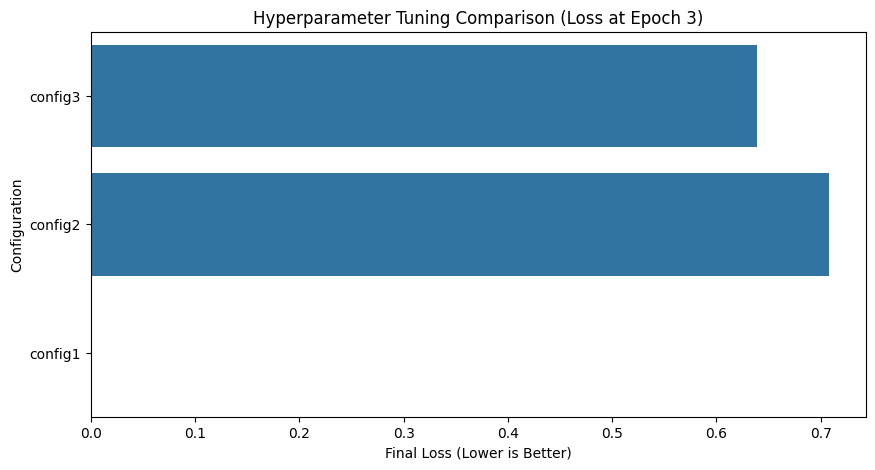


Best configuration found: config3


In [19]:
print("Project Requirement: Starting Hyperparameter Tuning")

# --- Configuration ---
# NUM_EPOCHS_TOTAL = NUM_EPOCHS_MASKRCNN
NUM_EPOCHS_TOTAL = 20 # Example: 20

# Set the number of epochs for THIS tuning experiment (e.g., 5)
NUM_EPOCHS_TUNING = 3
# Set the accumulation steps
accumulation_steps = 4

print(f"Tuning experiments will run for {NUM_EPOCHS_TUNING} epochs each.")
print(f"Final training will run for {NUM_EPOCHS_TOTAL} epochs.")

# Define the hyperparameter configurations to test
hyperparameter_configs = [
    {
        "name": "config1",
        "optimizer": "AdamW",
        "lr": 0.03,
        "weight_decay": 0.0005
    },
    {
        "name": "config2",
        "optimizer": "AdamW",
        "lr": 0.001,
        "weight_decay": 0.0005
    },
    {
        "name": "config3",
        "optimizer": "SGD",
        "lr": 0.001,
        "weight_decay": 0.0001
    }
]
dataset = SARD2YOLODataset(
        './dataset_augmente/images/train',
        './dataset_augmente/labels/train',
        target_size=640
    )

data_loader = DataLoader(
     dataset,
     batch_size=4,
     shuffle=True,
     num_workers=8,
     pin_memory=True,
    collate_fn=collate_fn
)
num_classes = NUM_CLASSES_MASKRCNN  # Ensure this is defined

# Start of Experiment Loop
print(f"Starting {len(hyperparameter_configs)} experiments")

results_history = []

for config in hyperparameter_configs:

    print(f"EXPERIMENT: {config['name']}")
    print(f"   Optimizer: {config['optimizer']}, LR: {config['lr']}, WD: {config['weight_decay']}")

    # 6. Define Model
    print("Initializing Mask R-CNN model")
    model = maskrcnn_resnet50_fpn(weights=True)

    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = torchvision.models.detection.faster_rcnn.FastRCNNPredictor(in_features, num_classes)
    in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
    hidden_layer = 256
    model.roi_heads.mask_predictor = torchvision.models.detection.mask_rcnn.MaskRCNNPredictor(in_features_mask, hidden_layer, num_classes)
    model.to(DEVICE)


    # Mixed precision scaler
    scaler = torch.amp.GradScaler("cuda")

    # 7. Optimizer (Uses config)
    params = [p for p in model.parameters() if p.requires_grad]

    if config['optimizer'] == 'AdamW':
        optimizer = torch.optim.AdamW(
            params, lr=config['lr'], weight_decay=config['weight_decay']
        )
    elif config['optimizer'] == 'SGD':
        optimizer = torch.optim.SGD(
            params, lr=config['lr'], momentum=0.9, weight_decay=config['weight_decay']
        )

    lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

    # 8. Training Loop (SHORT DURATION)

    # Run for the short tuning duration
    for epoch in range(NUM_EPOCHS_TUNING):
        model.train()
        epoch_loss = 0
        batch_count = 0
        optimizer.zero_grad(set_to_none=True) # Reset grads at epoch start

        pbar = tqdm(data_loader,
                    desc=f"Epoch {epoch+1}/{NUM_EPOCHS_TUNING} (Tuning {config['name']})",
                    ncols=100,
                    bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}, {rate_fmt}]')

        start_time = time.time()

        for batch_idx, batch in enumerate(pbar):
            if batch is None:
                continue

            torch.cuda.empty_cache()

            try:
                imgs, targets = batch
                imgs = list(img.to(DEVICE) for img in imgs)
                targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]

                # Mixed precision
                with torch.amp.autocast("cuda"):
                    loss_dict = model(imgs, targets)
                    losses = sum(loss for loss in loss_dict.values())

                    # Normalize loss for gradient accumulation
                    losses = losses / accumulation_steps

                # Accumulate gradients
                scaler.scale(losses).backward()

                # Update weights only every N steps
                if (batch_idx + 1) % accumulation_steps == 0:
                    scaler.step(optimizer)
                    scaler.update()
                    optimizer.zero_grad(set_to_none=True)

                del imgs, targets, loss_dict
                torch.cuda.empty_cache()

                # Update loss tracking
                epoch_loss += losses.item() * accumulation_steps
                batch_count += 1

                # Update progress bar
                avg_loss = epoch_loss / batch_count if batch_count > 0 else 0
                pbar.set_postfix({'Loss': f'{avg_loss:.4f}'})

            except RuntimeError as e:
                if "out of memory" in str(e):
                    print(f"WARNING: OOM error on batch {batch_idx}")
                    torch.cuda.empty_cache()
                    continue
                else:
                    raise e

        # End of epoch step (for remaining grads)
        if (batch_idx + 1) % accumulation_steps != 0:
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)

        epoch_time = time.time() - start_time
        avg_epoch_loss = epoch_loss / batch_count if batch_count > 0 else 0
        lr_scheduler.step()

    # End of the short training loop
    print(f"Tuning run finished for {config['name']}. Final Loss: {avg_epoch_loss:.4f}")

    # 9. Store Results
    results_history.append({
        'name': config['name'],
        f'loss_at_epoch_{NUM_EPOCHS_TUNING}': avg_epoch_loss
    })

    # Clean up memory before next experiment
    del model, optimizer, lr_scheduler, scaler
    torch.cuda.empty_cache()

# 10. Compare Tuning Results
print("All tuning experiments are finished.")
print("Comparison of results (based on final loss):")

results_df = pd.DataFrame(results_history).sort_values(by=f'loss_at_epoch_{NUM_EPOCHS_TUNING}', ascending=True)
print(results_df)

# Visualization (as required by project guidelines)
plt.figure(figsize=(10, 5))
sns.barplot(x=f'loss_at_epoch_{NUM_EPOCHS_TUNING}', y='name', data=results_df)
plt.title(f'Hyperparameter Tuning Comparison (Loss at Epoch {NUM_EPOCHS_TUNING})')
plt.xlabel('Final Loss (Lower is Better)')
plt.ylabel('Configuration')
plt.show()

# Extract the name of the best config
best_config_name = results_df.iloc[0]['name']
print(f"\nBest configuration found: {best_config_name}")

# Store the best config object for the next cell
try:
    best_config = next(c for c in hyperparameter_configs if c['name'] == best_config_name)
except StopIteration:
    print("Error: Could not find best_config. Using first config as default.")
    best_config = hyperparameter_configs[0]

### Final Model Training 

This code trains the Mask R-CNN model for the full 20 epochs using the best hyperparameters identified from the tuning experiments. It initializes a fresh model, applies the optimal optimizer settings (learning rate, weight decay), and runs the complete training loop with mixed precision and gradient accumulation. The model is saved periodically every 5 epochs as checkpoints and a final trained model is saved at the end, ready for evaluation and deployment.

In [20]:
# CELL 2: FINAL MODEL TRAINING (FULL RUN)
print("Starting final model training with the BEST hyperparameters")

# Check if 'best_config' exists from the previous cell
if 'best_config' not in locals():
    print("'best_config' not found. Please run the tuning cell above first")
    # Fallback: manually set the config if running this cell alone
else:
    print(f" Using config: {best_config['name']}")
    print(f"   Optimizer: {best_config['optimizer']}, LR: {best_config['lr']}, WD: {best_config['weight_decay']}")
    print(f"   Training for FULL {NUM_EPOCHS_TOTAL} epochs.")


# 6. Define Model
print("Initializing Mask R-CNN model")
model = maskrcnn_resnet50_fpn(weights=True)
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = torchvision.models.detection.faster_rcnn.FastRCNNPredictor(in_features, num_classes)
in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
hidden_layer = 256
model.roi_heads.mask_predictor = torchvision.models.detection.mask_rcnn.MaskRCNNPredictor(in_features_mask, hidden_layer, num_classes)
model.to(DEVICE)

scaler = torch.amp.GradScaler("cuda")

# 7. Optimizer (Final)
params = [p for p in model.parameters() if p.requires_grad]
if best_config['optimizer'] == 'AdamW':
    optimizer = torch.optim.AdamW(
        params, lr=best_config['lr'], weight_decay=best_config['weight_decay']
    )
elif best_config['optimizer'] == 'SGD':
    optimizer = torch.optim.SGD(
        params, lr=best_config['lr'], momentum=0.9, weight_decay=best_config['weight_decay']
    )
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

# 8. Training Loop
print(f"\n Starting FINAL training for {NUM_EPOCHS_TOTAL} epochs...\n")

for epoch in range(NUM_EPOCHS_TOTAL):
    model.train()
    epoch_loss = 0
    batch_count = 0
    optimizer.zero_grad(set_to_none=True)

    pbar = tqdm(data_loader,
                desc=f"Epoch {epoch+1}/{NUM_EPOCHS_TOTAL} (Final Model)",
                ncols=100,
                bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}, {rate_fmt}]')

    start_time = time.time()

    for batch_idx, batch in enumerate(pbar):
        if batch is None:
            continue

        torch.cuda.empty_cache()

        try:
            imgs, targets = batch
            imgs = list(img.to(DEVICE) for img in imgs)
            targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]

            with torch.amp.autocast("cuda"):
                loss_dict = model(imgs, targets)
                losses = sum(loss for loss in loss_dict.values())
                losses = losses / accumulation_steps

            scaler.scale(losses).backward()

            if (batch_idx + 1) % accumulation_steps == 0:
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad(set_to_none=True)

            del imgs, targets, loss_dict
            torch.cuda.empty_cache()

            epoch_loss += losses.item() * accumulation_steps
            batch_count += 1

            avg_loss = epoch_loss / batch_count if batch_count > 0 else 0
            pbar.set_postfix({'Loss': f'{avg_loss:.4f}'})

        except RuntimeError as e:
            if "out of memory" in str(e):
                print(f"WARNING: OOM error on batch {batch_idx}")
                torch.cuda.empty_cache()
                continue
            else:
                raise e

    # End of epoch step
    if (batch_idx + 1) % accumulation_steps != 0:
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad(set_to_none=True)

    epoch_time = time.time() - start_time
    avg_epoch_loss = epoch_loss / batch_count if batch_count > 0 else 0

    # Update learning rate
    lr_scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']

    print(f" Epoch {epoch+1}/{NUM_EPOCHS_TOTAL} finished | "
          f"Loss: {avg_epoch_loss:.4f} | "
          f"Time: {epoch_time:.1f}s | "
          f"LR: {current_lr:.6f}")

    # Periodic saving
    if (epoch + 1) % 5 == 0:
        checkpoint_path = f"mask_rcnn_checkpoint_epoch_{epoch+1}_{best_config['name']}.pth"
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': avg_epoch_loss,
        }, checkpoint_path)
        print(f"Checkpoint saved: {checkpoint_path}")


# 9. Save Final Model
final_model_name = f"mask_rcnn_FINAL_MODEL_{best_config['name']}.pth"
torch.save(model.state_dict(), final_model_name)
print(f" FINAL MODEL TRAINING COMPLETE! ")
print(f"Model saved to: {final_model_name}")

c:\Users\ac223162\AppData\Local\anaconda3\envs\mlenv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MaskRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=MaskRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Starting final model training with the BEST hyperparameters
 Using config: config3
   Optimizer: SGD, LR: 0.001, WD: 0.0001
   Training for FULL 20 epochs.
Initializing Mask R-CNN model

 Starting FINAL training for 20 epochs...



Epoch 1/20 (Final Model): 100%|███████████████████████████████████| 645/645 [07:07<00:00,  1.51it/s]


 Epoch 1/20 finished | Loss: 0.9644 | Time: 427.2s | LR: 0.001000


Epoch 2/20 (Final Model): 100%|███████████████████████████████████| 645/645 [07:09<00:00,  1.50it/s]


...

 Epoch 18/20 finished | Loss: 0.5314 | Time: 440.7s | LR: 0.000001


Epoch 19/20 (Final Model): 100%|██████████████████████████████████| 645/645 [07:22<00:00,  1.46it/s]


 Epoch 19/20 finished | Loss: 0.5328 | Time: 442.9s | LR: 0.000001


Epoch 20/20 (Final Model): 100%|██████████████████████████████████| 645/645 [07:27<00:00,  1.44it/s]


 Epoch 20/20 finished | Loss: 0.5315 | Time: 448.0s | LR: 0.000000
Checkpoint saved: mask_rcnn_checkpoint_epoch_20_config3.pth
 FINAL MODEL TRAINING COMPLETE! 
Model saved to: mask_rcnn_FINAL_MODEL_config3.pth


In [21]:
# === SSD Model Configuration ===

def get_ssd_model(num_classes):
    """
    Creates an SSD300 model with a VGG16 backbone.
    Arguments:
        num_classes (int): The number of classes in the dataset (including the background).
    """
    print("Initializing SSD300 with VGG16 backbone...")

    # 1. Load the pre-trained model
    # We use 'DEFAULT' weights which are pre-trained on the COCO dataset.
    # This helps the model converge faster (Transfer Learning).
    model = ssd300_vgg16(weights="DEFAULT")

    # 2. Configure the input channels for the new head
    # These numbers correspond to the output channels of the VGG16 layers used in SSD.
    # We do not need to change this unless we change the backbone.
    in_channels = [512, 1024, 512, 256, 256, 256]

    # 3. Retrieve the number of anchors
    # The anchor generator determines how many default boxes are placed at each location.
    num_anchors = model.anchor_generator.num_anchors_per_location()

    # 4. Replace the 'head' of the model
    # The head is responsible for classification and bounding box regression.
    # We replace it to match our specific number of classes.
    model.head = SSDHead(in_channels, num_anchors, num_classes)

    return model

In [23]:
# === SSD Training Loop (Robust Version) ===

# Hyperparameters for SSD
SSD_EPOCHS = 50
SSD_BATCH_SIZE = 4
SSD_MODEL_PATH = "ssd300_vgg16_final.pth"

dataset = SARD2YOLODataset(
        './dataset_augmente/images/train',
        './dataset_augmente/labels/train',
        target_size=640
    )

data_loader = DataLoader(
     dataset,
     batch_size=4,
     shuffle=True,
     num_workers=8,
     pin_memory=True,
    collate_fn=collate_fn
)

print(f"Starting SSD training for {SSD_EPOCHS} epochs...")

# 1. Initialize the model
# Ensure NUM_CLASSES_MASKRCNN matches your dataset (including background)
ssd_model = get_ssd_model(num_classes=NUM_CLASSES_MASKRCNN)
ssd_model.to(DEVICE)

# 2. Setup the Optimizer and Learning Rate Scheduler
optimizer_ssd = torch.optim.AdamW(ssd_model.parameters(), lr=0.0001, weight_decay=0.0005)
lr_scheduler_ssd = torch.optim.lr_scheduler.StepLR(optimizer_ssd, step_size=5, gamma=0.1)

# 3. Training Loop
for epoch in range(SSD_EPOCHS):
    ssd_model.train() # Set model to training mode
    epoch_total_loss = 0
    batch_count = 0

    optimizer_ssd.zero_grad()

    # Recreate DataLoader (good practice for shuffling)
    # Note: Ensure 'dataset' is defined and loaded from your previous cells
    train_loader_ssd = DataLoader(
        dataset,
        batch_size=SSD_BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        collate_fn=collate_fn
    )

    progress_bar = tqdm(train_loader_ssd, desc=f"Epoch {epoch+1}/{SSD_EPOCHS}", ncols=100)

    # === MODIFIED LOOP START ===
    # Instead of unpacking immediately "for images, targets in ...", we get the whole batch first.
    for batch in progress_bar:

        # Safety Check: Skip iteration if the batch is None or empty
        if batch is None or len(batch) == 0:
            continue

        # Now we can safely unpack the batch
        batch_images, batch_targets = batch
        # === MODIFIED LOOP END ===

        # Move data to the active device (GPU or CPU)
        images = list(image.to(DEVICE) for image in batch_images)
        targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in batch_targets]

        # Forward Pass
        loss_dict = ssd_model(images, targets)

        # Sum up losses
        total_batch_loss = sum(loss for loss in loss_dict.values())

        # Backward Pass
        optimizer_ssd.zero_grad()
        total_batch_loss.backward()
        optimizer_ssd.step()

        # Update statistics
        epoch_total_loss += total_batch_loss.item()
        batch_count += 1

        current_avg_loss = epoch_total_loss / batch_count
        progress_bar.set_postfix({'Avg Loss': f'{current_avg_loss:.4f}'})

    # Update the learning rate
    lr_scheduler_ssd.step()

    # Avoid division by zero if all batches were skipped
    avg_loss_print = epoch_total_loss/batch_count if batch_count > 0 else 0.0
    print(f"Epoch {epoch+1} completed. Final Average Loss: {avg_loss_print:.4f}")

# 4. Save the trained model
torch.save(ssd_model.state_dict(), SSD_MODEL_PATH)
print(f"Training complete. Model saved to: {SSD_MODEL_PATH}")

Starting SSD training for 50 epochs...
Initializing SSD300 with VGG16 backbone...


Epoch 1/50: 100%|████████████████████████████████| 645/645 [01:45<00:00,  6.11it/s, Avg Loss=8.5201]


Epoch 1 completed. Final Average Loss: 8.5201


Epoch 2/50: 100%|████████████████████████████████| 645/645 [01:47<00:00,  6.02it/s, Avg Loss=5.1250]


Epoch 2 completed. Final Average Loss: 5.1250


...

Epoch 48 completed. Final Average Loss: 1.6033


Epoch 49/50: 100%|███████████████████████████████| 645/645 [03:58<00:00,  2.70it/s, Avg Loss=1.6351]


Epoch 49 completed. Final Average Loss: 1.6351


Epoch 50/50: 100%|███████████████████████████████| 645/645 [03:47<00:00,  2.84it/s, Avg Loss=1.6267]

Epoch 50 completed. Final Average Loss: 1.6267
Training complete. Model saved to: ssd300_vgg16_final.pth


In [24]:
# === SSD Inference and Visualization ===

def detect_and_visualize_ssd(image_path, confidence_threshold=0.5):
    """
    Runs inference on a single image using the trained SSD model and visualizes the results.

    Arguments:
        image_path (str): Path to the input image.
        confidence_threshold (float): Minimum score to keep a detection (0.0 to 1.0).
    """
    # 1. Load the model architecture
    model = get_ssd_model(num_classes=NUM_CLASSES_MASKRCNN)

    # Load the trained weights
    if os.path.exists(SSD_MODEL_PATH):
        model.load_state_dict(torch.load(SSD_MODEL_PATH))
        print("SSD weights loaded successfully.")
    else:
        print("Warning: Trained weights not found. Using random weights.")

    # Set model to evaluation mode (disables Dropout, BatchNorm stats update, etc.)
    model.to(DEVICE)
    model.eval()

    # 2. Prepare the image
    # OpenCV reads in BGR, we need RGB
    original_image_bgr = cv2.imread(str(image_path))
    image_rgb = cv2.cvtColor(original_image_bgr, cv2.COLOR_BGR2RGB)

    # Convert to Tensor and move to device
    image_tensor = F.to_tensor(image_rgb).to(DEVICE)

    # 3. Perform Inference
    # We use 'no_grad' because we don't need gradients for inference (saves memory)
    with torch.no_grad():
        # The model expects a list of images
        predictions = model([image_tensor])

    # Predictions is a list (one per image). We only have one image, so take index 0.
    prediction = predictions[0]

    # 4. Process and Draw Detections
    annotated_image = image_rgb.copy()

    # Extract boxes, scores, and labels and move them to CPU/Numpy for processing
    boxes = prediction['boxes'].cpu().numpy()
    scores = prediction['scores'].cpu().numpy()
    labels = prediction['labels'].cpu().numpy()

    for i, box in enumerate(boxes):
        score = scores[i]

        # Filter out weak detections
        if score < confidence_threshold:
            continue

        # Get box coordinates
        x_min, y_min, x_max, y_max = box.astype(int)

        # Get class name
        # Note: SSD output class '1' corresponds to our class '0' (dataset index),
        # because '0' is reserved for background in SSD.
        # We adjust the index by subtracting 1.
        label_index = labels[i] - 1
        class_name = CLASSES.get(label_index, f"Class {label_index}")

        # Draw the bounding box (Red color)
        cv2.rectangle(annotated_image, (x_min, y_min), (x_max, y_max), (255, 0, 0), 2)

        # Draw the label and score
        text = f"SSD: {class_name} ({score:.2f})"
        cv2.putText(annotated_image, text, (x_min, y_min - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 2)

    # 5. Save the result
    output_filename = "ssd_detection_result.jpg"
    # Convert back to BGR for OpenCV saving
    cv2.imwrite(output_filename, cv2.cvtColor(annotated_image, cv2.COLOR_RGB2BGR))
    print(f"Result saved as {output_filename}")

    return annotated_image



# Step 4: Prediction and Visualization

Using the trained models (YOLO and Mask R-CNN) to make predictions on a test image.

In [25]:
def detect_image_yolo(img_path):

    try:
        model = YOLO(YOLO_BEST_PT)
    except NameError:
        print("Erreur: 'YOLO_BEST_PT' n'est pas défini.")
        img_bgr = cv2.imread(img_path)
        if img_bgr is None:
             raise FileNotFoundError(f"Could not read image: {img_path}")
        return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    results = model(img_path, conf=0.25)


    # 1. Read original image
    img_bgr = cv2.imread(img_path)
    if img_bgr is None:
        raise FileNotFoundError(f"Could not read image: {img_path}")
    annotated_img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # 2.classes map
    try:
        classes_map_yolo = classes
    except NameError:
        classes_map_yolo = results[0].names
        if classes_map_yolo is None:
            print("Warning: 'classes' map not found. Using default names.")
            classes_map_yolo = {0: "class_0"}

    # 3. More detections
    detections = results[0].boxes

    for i, detection in enumerate(detections):
        # Extract informations of the detections
        box = detection.xyxy[0].cpu().numpy().astype(int)
        xmin, ymin, xmax, ymax = box
        score = detection.conf[0].cpu().numpy()
        class_idx = int(detection.cls[0].cpu().numpy())

        class_name = classes_map_yolo.get(class_idx, str(class_idx))

        # 4. Random color
        rnd = (class_idx * 37 + i * 17) % 255
        color = (int((rnd * 97) % 255), int((rnd * 67) % 255), int((rnd * 137) % 255))

        cv2.rectangle(annotated_img, (xmin, ymin), (xmax, ymax), color, 2)


        # 6. Define text
        txt = f"{class_name} {score:.2f}"

        # 7. size of text
        font = cv2.FONT_HERSHEY_SIMPLEX
        font_scale = 0.5
        font_thickness = 1
        (w, h), baseline = cv2.getTextSize(txt, font, font_scale, font_thickness)

        # 8. text not on top
        t_ymin = max(ymin - h - 6, 0)

        # 9. draw the rectangle
        cv2.rectangle(annotated_img,
                      (xmin, t_ymin),
                      (xmin + w, t_ymin + h + baseline + 3),
                      color,
                      -1)

        # 10. Draw the text
        cv2.putText(annotated_img,
                    txt,
                    (xmin, t_ymin + h + 1),
                    font,
                    font_scale,
                    (255, 255, 255),
                    font_thickness,
                    cv2.LINE_AA)



    cv2.imwrite("annotated_test.jpg", cv2.cvtColor(annotated_img, cv2.COLOR_RGB2BGR))
    print("Saved -> annotated_test.jpg")


    return annotated_img

# `detect_image_yolo()` Function

## Purpose
Performs object detection on an image using a YOLO model and returns the image annotated with bounding boxes, class labels, and confidence scores.

## Parameters
- `img_path` (str): Path to the input image

## Returns
- Annotated RGB image (numpy array) with visual detection results

## What it does
1. Loads the YOLO model from `YOLO_BEST_PT`
2. Runs object detection with 0.25 confidence threshold
3. Draws colored bounding boxes around detected objects
4. Adds text labels showing class name and confidence score
5. Saves result as "annotated_test.jpg"
6. Returns the annotated image

In [26]:

def detect_image_maskrcnn(img_path):
    checkpoint_path = "mask_rcnn_sard2_yolo_final.pth"

    # Load checkpoint and infer num_classes from it
    if os.path.exists(checkpoint_path):
        state = torch.load(checkpoint_path, map_location='cpu')
        sd = state['model_state_dict'] if isinstance(state, dict) and 'model_state_dict' in state else state

        # Try to find the cls_score weight key to infer number of classes
        cls_key = None
        for k in sd.keys():
            if k.endswith('roi_heads.box_predictor.cls_score.weight') or 'cls_score.weight' in k:
                cls_key = k
                break

        if cls_key is not None:
            nc = sd[cls_key].shape[0]
            print(f"Inferred num_classes from checkpoint: {nc}")
        else:
            # Fallback to global / configured value
            try:
                nc = num_classes
            except NameError:
                try:
                    nc = NUM_CLASSES_MASKRCNN
                except NameError:
                    nc = 2
            print(f"Could not infer num_classes from checkpoint, using nc={nc}")

        # Build model with inferred num_classes
        model = maskrcnn_resnet50_fpn(weights=None, num_classes=nc)

        # Load state dict, try strict=True then strict=False if mismatch
        try:
            model.load_state_dict(sd)
            print("Checkpoint loaded with strict=True")
        except Exception as e:
            print("Strict load failed (likely head size mismatch). Loading with strict=False and keeping unmatched heads reinitialized.")
            missing = model.load_state_dict(sd, strict=False)
            print("Missing keys / unexpected keys:", missing)
    else:
        print(f"Checkpoint not found: {checkpoint_path}. Building model with default num_classes.")
        try:
            nc = num_classes
        except NameError:
            nc = NUM_CLASSES_MASKRCNN if 'NUM_CLASSES_MASKRCNN' in globals() else 2
        model = maskrcnn_resnet50_fpn(weights=None, num_classes=nc)

    # Ensure device variable exists
    device_to_use = DEVICE if 'DEVICE' in globals() else torch.device('cpu')
    model.to(device_to_use)
    model.eval()

    # Use the CLASSES mapping defined in cell 2 if available
    if 'CLASSES' in globals():
        classes_map = CLASSES
    else:
        # fallback: build mapping from inferred nc (nc includes background)
        original_classes = max(0, nc - 1)
        classes_map = {i: f"class_{i}" for i in range(original_classes)}

    # Read and prepare image for Mask R-CNN
    img_bgr = cv2.imread(img_path)
    if img_bgr is None:
        raise FileNotFoundError(f"Could not read image: {img_path}")
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    H, W = img_rgb.shape[:2]

    # Convert to tensor expected by torchvision
    img_tensor = torchvision.transforms.functional.to_tensor(img_rgb).to(device_to_use)

    with torch.no_grad():
        outputs = model([img_tensor])

    out = outputs[0]
    scores = out.get('scores', torch.tensor([])).cpu()
    boxes = out.get('boxes', torch.tensor([])).cpu()
    labels = out.get('labels', torch.tensor([])).cpu()
    masks = out.get('masks', None)
    if masks is not None:
        masks = masks.cpu()

    # Filter by score threshold
    score_thresh = 0.5
    keep = (scores >= score_thresh).nonzero(as_tuple=False).squeeze(1)

    annotated = img_rgb.copy()

    if keep.numel() == 0:
        print("No detections above threshold")
    else:
        boxes = boxes[keep].numpy().astype(int)
        scores = scores[keep].numpy()
        labels = labels[keep].numpy()
        if masks is not None:
            masks = masks[keep].numpy()  # shape [N,1,H,W]

        alpha = 0.5
        for i, box in enumerate(boxes):
            xmin, ymin, xmax, ymax = box
            score = scores[i]
            label = int(labels[i])

            # Mask R-CNN labels include background at 0, training used +1 for real classes
            class_idx = label - 1
            class_name = classes_map.get(class_idx, f"class_{class_idx}")

            rnd = (class_idx * 37 + i * 17) % 255
            color = (int((rnd * 97) % 255), int((rnd * 67) % 255), int((rnd * 137) % 255))

            # Draw box and label (YOLO-style background)
            cv2.rectangle(annotated, (xmin, ymin), (xmax, ymax), color, 2)
            txt = f"{class_name} {score:.2f}"
            font = cv2.FONT_HERSHEY_SIMPLEX
            font_scale = 0.5
            font_thickness = 1
            (w, h), baseline = cv2.getTextSize(txt, font, font_scale, font_thickness)
            t_ymin = max(ymin - h - 6, 0)
            cv2.rectangle(annotated,
                          (xmin, t_ymin),
                          (xmin + w, t_ymin + h + baseline + 3),
                          color,
                          -1)
            cv2.putText(annotated,
                        txt,
                        (xmin, t_ymin + h + 1),
                        font,
                        font_scale,
                        (255, 255, 255),
                        font_thickness,
                        cv2.LINE_AA)

            # Draw mask if present
            if masks is not None:
                mask = masks[i][0]  # [H,W]
                mask_bin = (mask >= 0.3).astype('uint8')
                if mask_bin.sum() > 0:
                    colored_mask = np.zeros_like(annotated, dtype=np.uint8)
                    colored_mask[:, :] = color
                    annotated = np.where(mask_bin[:, :, None].astype(bool),
                                         (annotated * (1 - alpha) + colored_mask * alpha).astype(np.uint8),
                                         annotated)

    # Save Mask R-CNN result
    out_bgr = cv2.cvtColor(annotated, cv2.COLOR_RGB2BGR)
    out_fname = "annotated_maskrcnn.jpg"
    cv2.imwrite(out_fname, out_bgr)
    print(f"Annotated image saved -> {out_fname}")

    return annotated

# `detect_image_maskrcnn()` Function

## Purpose
Performs instance segmentation on an image using a Mask R-CNN model and returns the image annotated with bounding boxes, class labels, confidence scores, and segmentation masks.

## Parameters
- `img_path` (str): Path to the input image

## Returns
- Annotated RGB image (numpy array) with bounding boxes, labels, and semi-transparent colored masks overlay

## What it does
1. Loads a pre-trained Mask R-CNN model from checkpoint (`mask_rcnn_sard2_yolo_final.pth`)
2. Automatically infers the number of classes from the checkpoint
3. Runs instance segmentation with 0.5 confidence threshold
4. For each detected object:
   - Draws colored bounding boxes
   - Adds text labels with class name and confidence score
   - Overlays semi-transparent colored masks (50% opacity) on detected regions
5. Saves result as "annotated_maskrcnn.jpg"
6. Returns the annotated image

## Key Difference from YOLO
Unlike YOLO which only provides bounding boxes, this function also generates pixel-level segmentation masks for each detected object, showing the exact shape and contour of instances.

Image test: ./dataset/images/test\gss1383_jpg.rf.b4034e52ba3e29c242329d887e9c2778.jpg

image 1/1 c:\Users\ac223162\Desktop\esilv\annee_4\machine_learning\Projet\dataset\images\test\gss1383_jpg.rf.b4034e52ba3e29c242329d887e9c2778.jpg: 384x640 1 Walking, 1 laying_down, 1 seated, 320.5ms
Speed: 2.7ms preprocess, 320.5ms inference, 4.8ms postprocess per image at shape (1, 3, 384, 640)
Saved -> annotated_test.jpg
Checkpoint not found: mask_rcnn_sard2_yolo_final.pth. Building model with default num_classes.
No detections above threshold
Annotated image saved -> annotated_maskrcnn.jpg
Initializing SSD300 with VGG16 backbone...
SSD weights loaded successfully.
Result saved as ssd_detection_result.jpg


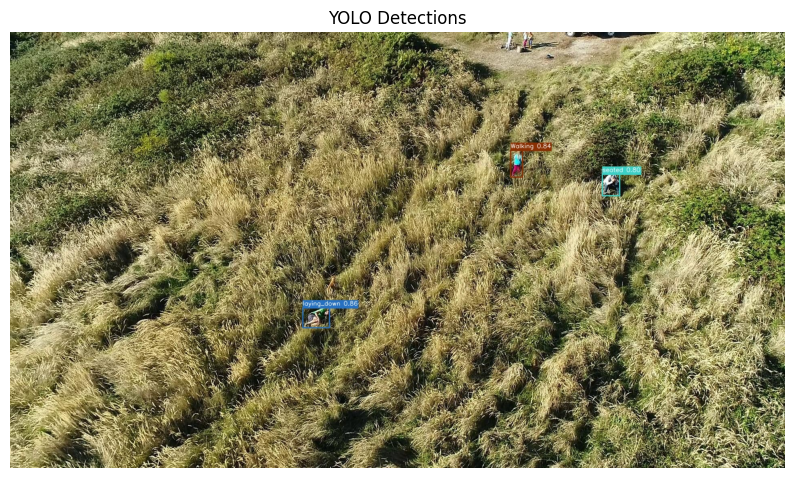

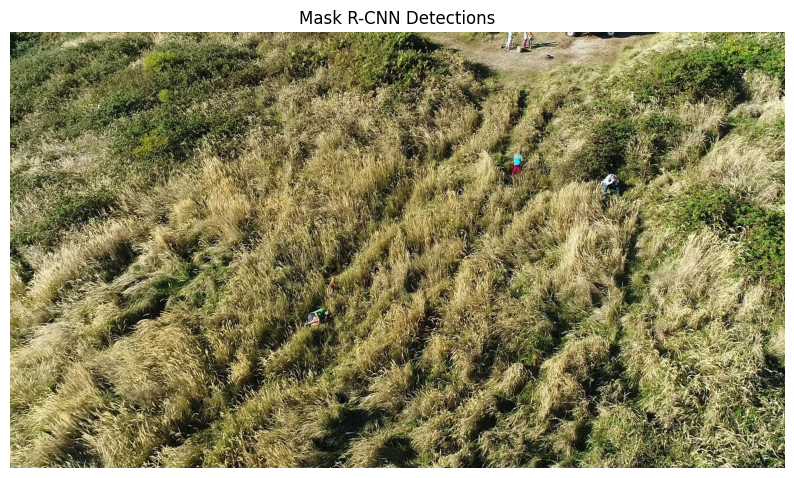

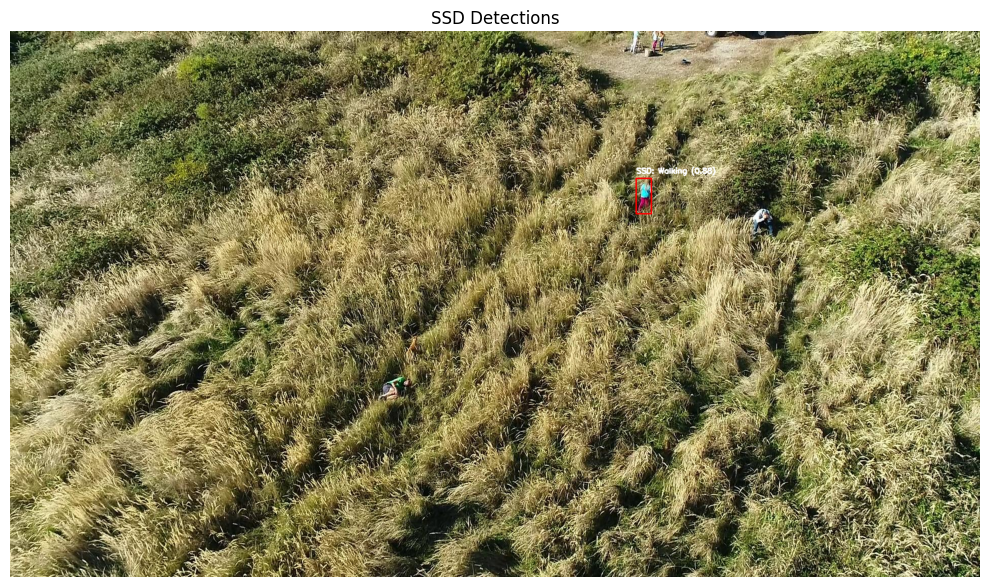

In [29]:
# select a random test image
img_paths = glob.glob("./dataset/images/test/*.jpg")
img_path = random.choice(img_paths)
print(f"Image test: {img_path}")
# Run YOLO detection
annotated_img=detect_image_yolo(img_path=img_path)
# Run Mask R-CNN detection
annotated=detect_image_maskrcnn(img_path=img_path)
annotated_ssd=detect_and_visualize_ssd(img_path)

plt.figure(figsize=(10,8))
plt.imshow(cv2.cvtColor(cv2.imread("annotated_test.jpg"), cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title("YOLO Detections")

plt.figure(figsize=(10,8))
plt.imshow(annotated)
plt.axis('off')
plt.title("Mask R-CNN Detections")

plt.figure(figsize=(10,8))
plt.imshow(annotated_ssd)
plt.axis('off')
plt.title("SSD Detections")
plt.tight_layout()
plt.show()

--- Evaluating YOLO ---
Ultralytics 8.3.209  Python-3.11.13 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
YOLO11n summary (fused): 100 layers, 2,583,322 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 1027.6196.4 MB/s, size: 921.8 KB)
val: Scanning C:\Users\ac223162\Desktop\esilv\annee_4\machine_learning\Projet\dataset_augmente\labels\test.cache... 395 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 395/395  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 2.6it/s 9.7s0.4s
                   all        395       1214      0.744      0.613      0.669      0.399
               Running         13         19      0.897      0.105      0.265      0.134
               Walking        138        214      0.599      0.579      0.576      0.315
           laying_down        210        292      0.842      0.836      0.896      0.592
           not_defined        1

Mask R-CNN Eval: 100%|██████████| 198/198 [03:05<00:00,  1.07it/s]



--- Evaluating SSD ---
Initializing SSD300 with VGG16 backbone...
SSD weights loaded.


SSD Eval:   0%|          | 0/198 [00:00<?, ?it/s]c:\Users\ac223162\AppData\Local\anaconda3\envs\mlenv\Lib\site-packages\torchmetrics\utilities\prints.py:43: UserWarning: Encountered more than 100 detections in a single image. This means that certain detections with the lowest scores will be ignored, that may have an undesirable impact on performance. Please consider adjusting the `max_detection_threshold` to suit your use case. To disable this warning, set attribute class `warn_on_many_detections=False`, after initializing the metric.
  warnings.warn(*args, **kwargs)
SSD Eval: 100%|██████████| 198/198 [00:34<00:00,  5.71it/s]



Comparison on augmented images :
             mAP@50-95    mAP@50  Precision    Recall
YOLO         0.398984  0.669108   0.743834  0.613461
Mask R-CNN   0.212557  0.427239   0.212557  0.875000
SSD          0.213545  0.465293   0.213545  0.550000


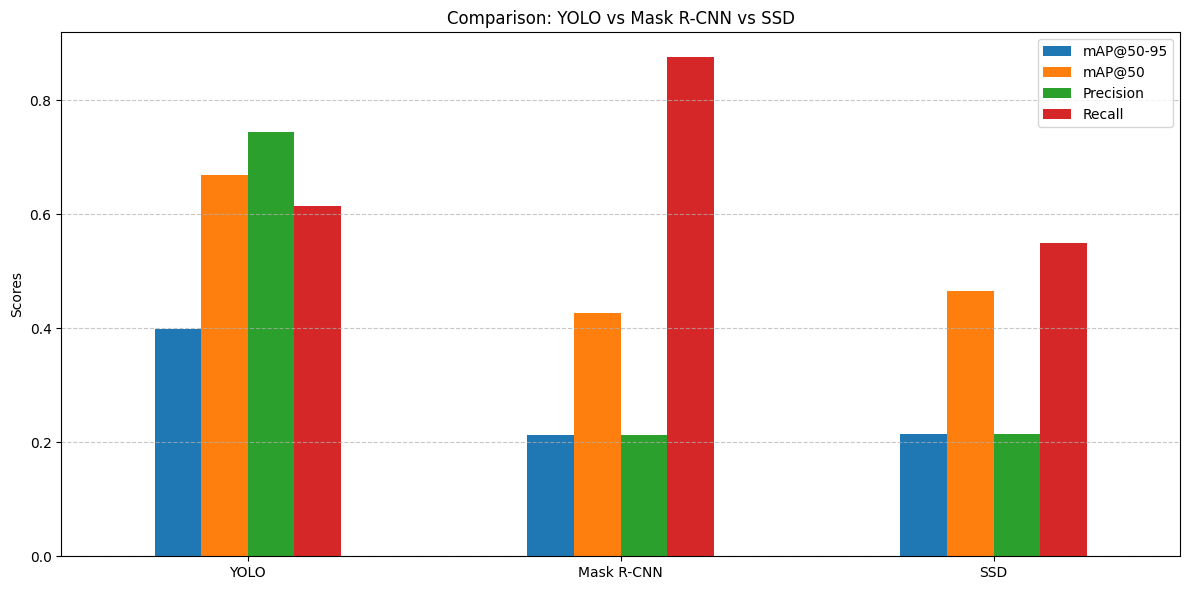


Detection Visualization (Random Samples)

image 1/1 c:\Users\ac223162\Desktop\esilv\annee_4\machine_learning\Projet\dataset_augmente\images\test\gss1826_jpg.rf.7dc60148b63e7c95d0653df172c5fa29.jpg: 384x640 1 laying_down, 4 standss, 24.4ms
Speed: 2.9ms preprocess, 24.4ms inference, 3.3ms postprocess per image at shape (1, 3, 384, 640)
Saved -> annotated_test.jpg
Checkpoint not found: mask_rcnn_sard2_yolo_final.pth. Building model with default num_classes.
No detections above threshold
Annotated image saved -> annotated_maskrcnn.jpg
Initializing SSD300 with VGG16 backbone...
SSD weights loaded successfully.
Result saved as ssd_detection_result.jpg


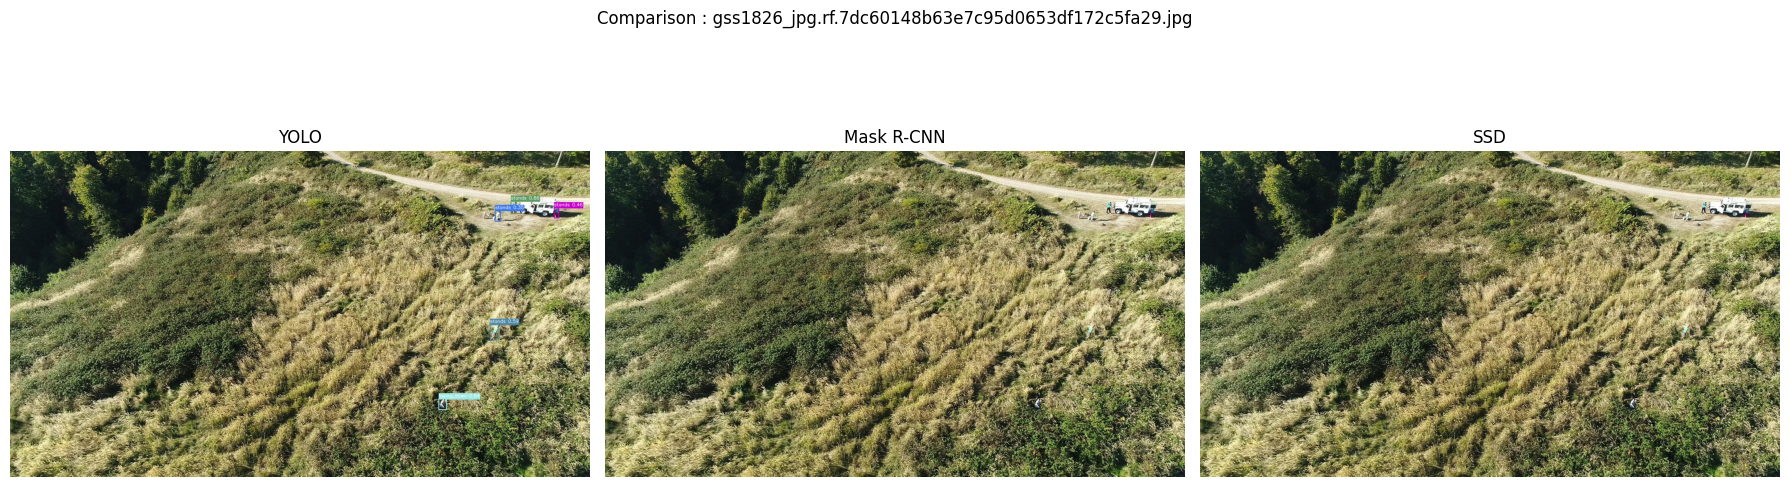


image 1/1 c:\Users\ac223162\Desktop\esilv\annee_4\machine_learning\Projet\dataset_augmente\images\test\gss1293_jpg.rf.4408195e74c6b71716f49c721408f42d_fog0.71_46.jpg: 384x640 1 seated, 29.4ms
Speed: 3.0ms preprocess, 29.4ms inference, 14.4ms postprocess per image at shape (1, 3, 384, 640)
Saved -> annotated_test.jpg
Checkpoint not found: mask_rcnn_sard2_yolo_final.pth. Building model with default num_classes.
No detections above threshold
Annotated image saved -> annotated_maskrcnn.jpg
Initializing SSD300 with VGG16 backbone...
SSD weights loaded successfully.
Result saved as ssd_detection_result.jpg


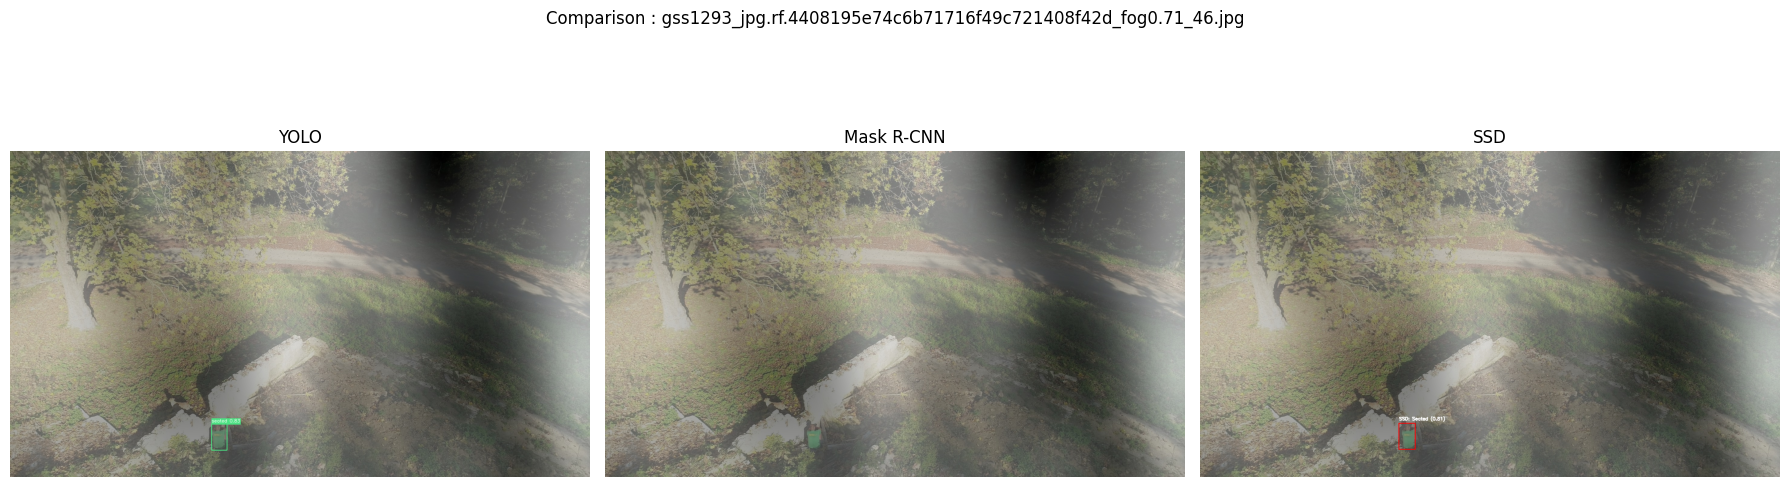


image 1/1 c:\Users\ac223162\Desktop\esilv\annee_4\machine_learning\Projet\dataset_augmente\images\test\gss90_jpg.rf.790a59d80bfad5b02787b119f23459be_fog0.67_5.jpg: 384x640 1 Walking, 1 seated, 1 stands, 26.4ms
Speed: 3.5ms preprocess, 26.4ms inference, 4.5ms postprocess per image at shape (1, 3, 384, 640)
Saved -> annotated_test.jpg
Checkpoint not found: mask_rcnn_sard2_yolo_final.pth. Building model with default num_classes.
No detections above threshold
Annotated image saved -> annotated_maskrcnn.jpg
Initializing SSD300 with VGG16 backbone...
SSD weights loaded successfully.
Result saved as ssd_detection_result.jpg


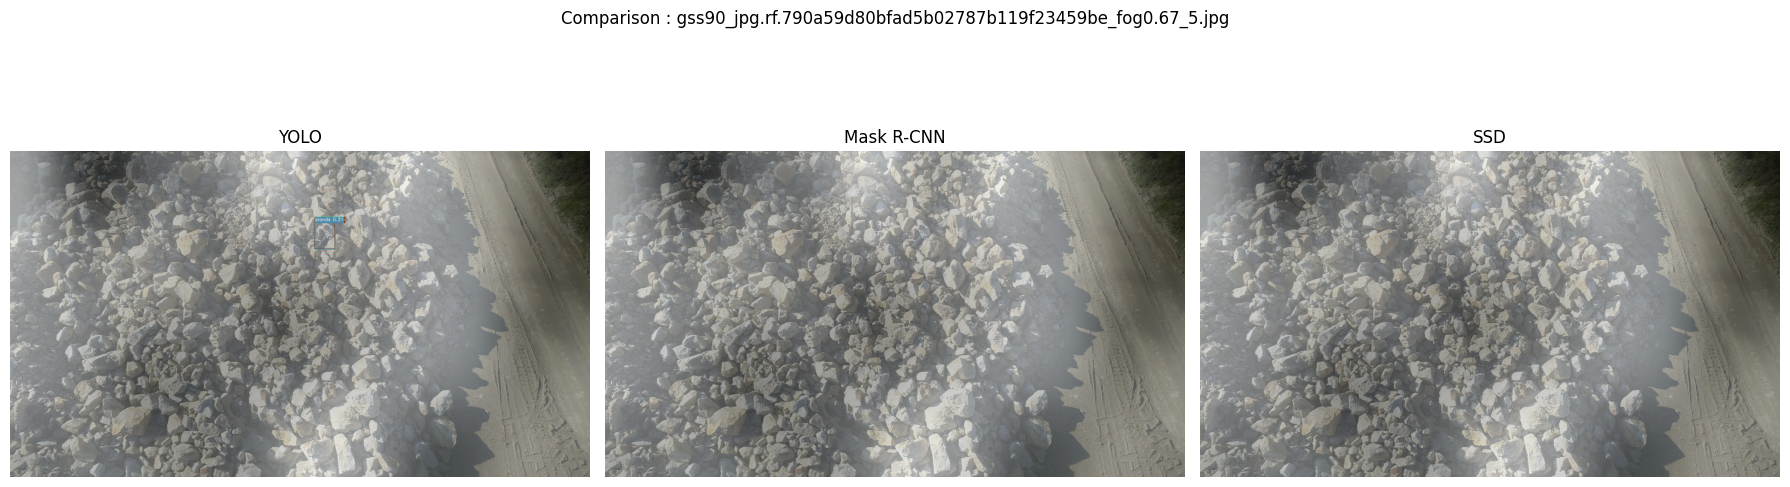

In [32]:
# === CONFIGURATION ===
torch.cuda.empty_cache()
DATA_YAML = "data.yaml"
YOLO_BEST_PT = 'runs/train/sard2_yolo11_augmented/weights/best.pt'
MASK_RCNN_PATH = "mask_rcnn_FINAL_MODEL_config3.pth"
SSD_MODEL_PATH = "ssd300_vgg16_final.pth" # Path to the saved SSD model
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
NUM_CLASSES_MASKRCNN = 7
IMG_DIR = './dataset_augmente/images/test'
LBL_DIR = './dataset_augmente/labels/test'

# === 1. Evaluation YOLO ===
print("--- Evaluating YOLO ---")
yolo_model = YOLO(YOLO_BEST_PT)
metrics_yolo = yolo_model.val(split='test', data=DATA_YAML)

yolo_results = {
    "mAP@50-95": metrics_yolo.box.map,
    "mAP@50": metrics_yolo.box.map50,
    "Precision": np.mean(metrics_yolo.box.p),
    "Recall": np.mean(metrics_yolo.box.r)
}
torch.cuda.empty_cache()

# === 2. Evaluation MASK R-CNN ===
print("\n--- Evaluating Mask R-CNN ---")
# Prepare Dataset and Loader (Shared with SSD)
test_dataset = SARD2YOLODataset(IMG_DIR, LBL_DIR)
test_loader = DataLoader(test_dataset, batch_size=2, shuffle=False, collate_fn=collate_fn)

# Load Mask R-CNN
mask_model = maskrcnn_resnet50_fpn(weights=None, num_classes=NUM_CLASSES_MASKRCNN)
mask_model.load_state_dict(torch.load(MASK_RCNN_PATH, map_location=DEVICE))
mask_model.to(DEVICE).eval()

# Metric object
metric_mask = MeanAveragePrecision(iou_type="bbox").to(DEVICE)

with torch.no_grad():
    for images, targets in tqdm(test_loader, desc="Mask R-CNN Eval"):
        images = [img.to(DEVICE) for img in images]
        targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]
        preds = mask_model(images)
        metric_mask.update(preds, targets)

results_mask_raw = metric_mask.compute()

# Storing results (using same keys as YOLO for consistency)
mask_results = {
    "mAP@50-95": results_mask_raw['map'].item(),
    "mAP@50": results_mask_raw['map_50'].item(),
    "Precision": results_mask_raw['map'].item(),       # Using mAP as proxy for Precision (as in your code)
    "Recall": results_mask_raw['mar_large'].item(),    # Using MAR Large as proxy for Recall
}

# === 3. Evaluation SSD (NEW) ===
print("\n--- Evaluating SSD ---")

# Load SSD Model
# We use the helper function defined in previous cells
ssd_model = get_ssd_model(num_classes=NUM_CLASSES_MASKRCNN)
if os.path.exists(SSD_MODEL_PATH):
    ssd_model.load_state_dict(torch.load(SSD_MODEL_PATH, map_location=DEVICE))
    print("SSD weights loaded.")
else:
    print("Warning: SSD weights not found, results will be poor.")

ssd_model.to(DEVICE).eval()

# Metric object for SSD
metric_ssd = MeanAveragePrecision(iou_type="bbox").to(DEVICE)

with torch.no_grad():
    for batch in tqdm(test_loader, desc="SSD Eval"):
        # Safety check for empty batches
        if batch is None or len(batch) == 0:
            continue

        images, targets = batch
        images = [img.to(DEVICE) for img in images]
        targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]

        # SSD Inference
        preds = ssd_model(images)

        # Update metric
        metric_ssd.update(preds, targets)

results_ssd_raw = metric_ssd.compute()

ssd_results = {
    "mAP@50-95": results_ssd_raw['map'].item(),
    "mAP@50": results_ssd_raw['map_50'].item(),
    "Precision": results_ssd_raw['map'].item(),       # Consistent with Mask R-CNN logic
    "Recall": results_ssd_raw['mar_large'].item(),    # Consistent with Mask R-CNN logic
}

# === 4. COMPARISON ===
# Create DataFrame with 3 models
df = pd.DataFrame([yolo_results, mask_results, ssd_results], index=["YOLO", "Mask R-CNN", "SSD"])
print("\nComparison on augmented images :\n", df)

# Plot Bar Chart
df.plot(kind="bar", figsize=(12, 6), title="Comparison: YOLO vs Mask R-CNN vs SSD")
plt.xticks(rotation=0)
plt.ylabel("Scores")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# === 5. VISUALIZATION ===
print("\nDetection Visualization (Random Samples)")

sample_imgs = random.sample(glob.glob(f"{IMG_DIR}/*.jpg"), 3)

for img_path in sample_imgs:
    # Run inference for all 3 models
    yolo_img = detect_image_yolo(img_path)
    mask_img = detect_image_maskrcnn(img_path)
    # Using the function name from the previous step
    ssd_img = detect_and_visualize_ssd(img_path)

    # Create a figure with 3 columns
    plt.figure(figsize=(18, 6))

    plt.subplot(1, 3, 1)
    plt.imshow(yolo_img)
    plt.title("YOLO")
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(mask_img)
    plt.title("Mask R-CNN")
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(ssd_img)
    plt.title("SSD")
    plt.axis('off')

    plt.suptitle(f"Comparison : {os.path.basename(img_path)}")
    plt.tight_layout()
    plt.show()

# Code Purpose: Complete Model Evaluation and Comparison Pipeline

This code performs a comprehensive evaluation and comparison between two object detection models (YOLO and Mask R-CNN) on a test dataset. It starts by configuring paths to the trained models, dataset locations, and computing device (GPU/CPU), along with clearing GPU memory. The code then evaluates the YOLO model by loading it and running validation on the test split, extracting performance metrics including mAP@50-95, mAP@50, Precision, and Recall. Next, it evaluates the Mask R-CNN model by loading the test dataset, running inference on all test images, and computing the same metrics using torchmetrics. After both evaluations are complete, it creates a side-by-side comparison table (DataFrame) displaying all metrics for both models and generates a bar chart to visualize the performance differences. Finally, it randomly selects 3 test images and runs both models on them, displaying side-by-side visualizations showing YOLO detections on the left and Mask R-CNN detections with segmentation masks on the right. The entire process provides both quantitative (numerical metrics and charts) and qualitative (visual detection results) comparisons to help determine which model performs better on the specific dataset.